# Trabajo Práctico: Desarrollo de un Modelo Predictivo Vinculado al TFM
---
### Máster en Big Data & Business Intelligence 2025/2026  
### Asignatura 7: Modelado Predictivo con Machine Learning 
**Universidad:** Next Educación  
**Curso académico:** Febrero 2026  
**Integrantes - Grupo 2:** Alejandra Arce, David Chaverri, André Plannerer, Elian Rocha y Sergio Solórzano.  
**Fecha de entrega:** 4 de Octubre, 2026 

---

Este cuaderno está dividido en dos secciones de contenido:
1. El conjunto de consultas y resultados que se utilizaron para **análisis preeliminar de datos** presentes en la base de datos construida a partir de información histórica de SICOP (proveedores, instituciones, carteles, ofertas y adjudicaciones).
2. Un conjunto de consultas para la **construcción del data set final con el que se entrenó un modelo predictivo de clasificación (Random Forest)** para calcular la probabilidad de adjudicación que tendrán ofertas presentadas pero que aún no han sido adjudicadas. En esta misma sección se evaluá y selecciona el mejor conjunto de hiperparámetros para el modelo y además se grafican los resultados de evaluación del modelo.

---

## 1. Análisis preeliminar de datos

Cómo primer paso, será necesario descargar, en su computadora, la base de datos publicada en el siguiente release del repositorio: [Base de datos SICOP](https://github.com/ssolorzanocr/Modelo_predictivo_SICOP/releases/download/datos_actuales_sicop/sicop.duckdb)  
Para efectos de este cuaderno, la base de datos utilizada posee <u>registros que comprenden un periodo desde Enero 2025 hasta Septiembre del 2026</u> (21 meses).

Luego, **debe instalar las librerías para ejecutar los fragmentos de código python en este cuaderno de Jupiter**:  
`python -m pip install --upgrade pip`
`pip install duckdb pandas matplotlib scikit-learn jinja2`

Ahora, se crea una conexión a la base de datos local en el ordenador e imprimimos las tablas disponibles del modelo de datos.

In [4]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from dotenv import load_dotenv
import os

load_dotenv()

RUTA_BASE_DE_DATOS = os.getenv("RUTA_DATOS")
print(f"Ruta de la base de datos: {RUTA_BASE_DE_DATOS}")

con = duckdb.connect(
    RUTA_BASE_DE_DATOS,
    read_only=True
)

Ruta de la base de datos: localdata\sicop.duckdb


Exploramos el contenido de la base de datos a nivel general.  
Observamos que hay dos schemas en la base datos. Para efectos de este cuaderno solo nos interesa el schema llamado 'final'.  

In [29]:
con.sql("SHOW ALL TABLES").df()

,database,schema,name,column_names,column_types,temporary
0,sicop,final,dim_instituciones,"[cedula, nombre_institucion, zona_geo_inst, fe...","[VARCHAR, VARCHAR, VARCHAR, DATE, BIGINT]",False
1,sicop,final,dim_productos,"[cod_producto, descripcion_producto, segmento,...","[BIGINT, VARCHAR, INTEGER, VARCHAR]",False
2,sicop,final,dim_proveedores,"[cedula_proveedor, nombre_proveedor, tipo_prov...","[VARCHAR, VARCHAR, VARCHAR, VARCHAR, VARCHAR, ...",False
3,sicop,final,fact_lineas_adjudicadas,"[nro_sicop, nro_linea, nro_oferta, cedula_inst...","[VARCHAR, VARCHAR, VARCHAR, VARCHAR, VARCHAR, ...",False
4,sicop,final,fact_lineas_carteles,"[nro_sicop, numero_linea, numero_partida, cedu...","[VARCHAR, VARCHAR, VARCHAR, VARCHAR, DATE, VAR...",False
5,sicop,final,fact_lineas_ofertas,"[nro_sicop, nro_oferta, nro_linea, cedula_prov...","[VARCHAR, VARCHAR, VARCHAR, VARCHAR, DATE, VAR...",False
6,sicop,staging,dim_instituciones,"[cedula, nombre_institucion, zona_geo_inst, fe...","[VARCHAR, VARCHAR, VARCHAR, VARCHAR, VARCHAR]",False
7,sicop,staging,dim_proveedores,"[cedula_proveedor, nombre_proveedor, tipo_prov...","[VARCHAR, VARCHAR, VARCHAR, VARCHAR, VARCHAR, ...",False
8,sicop,staging,fact_adjudicaciones,"[nro_sicop, cedula, numero_procedimiento, desc...","[VARCHAR, VARCHAR, VARCHAR, VARCHAR, VARCHAR, ...",False
9,sicop,staging,fact_carteles,"[nro_sicop, cedula_institucion, fecha_publicac...","[VARCHAR, VARCHAR, VARCHAR, VARCHAR, VARCHAR, ...",False


Mostramos ahora las columnas de datos en el schema final:

In [30]:
pd.set_option("display.max_rows", None)

con.sql("""
    SELECT
        database_name,
        schema_name,
        table_name,
        column_name,
        data_type
    FROM duckdb_columns()
    WHERE NOT internal and schema_name = 'final'
    ORDER BY table_name
""").df()

,database_name,schema_name,table_name,column_name,data_type
0,sicop,final,dim_instituciones,cedula,VARCHAR
1,sicop,final,dim_instituciones,nombre_institucion,VARCHAR
2,sicop,final,dim_instituciones,zona_geo_inst,VARCHAR
3,sicop,final,dim_instituciones,fecha_ingreso,DATE
4,sicop,final,dim_instituciones,proveedores_adjudicados_distintos,BIGINT
5,sicop,final,dim_productos,cod_producto,BIGINT
6,sicop,final,dim_productos,descripcion_producto,VARCHAR
7,sicop,final,dim_productos,segmento,INTEGER
8,sicop,final,dim_productos,nombre_segmento,VARCHAR
9,sicop,final,dim_proveedores,porcentaje_exito,DOUBLE


Exploremos la cantidad de registros y cantidad de valores nulos para cada tabla en el periodo estudiado.

In [31]:
for table in con.sql("""
    SELECT
        database_name,
        schema_name,
        table_name,
        column_name,
        data_type
    FROM duckdb_columns()
    WHERE NOT internal and schema_name = 'final'
    ORDER BY table_name
    """).df().table_name.unique():
    print("__________________________________")
    print(f"Registros en final.{table}: {con.sql(f'SELECT COUNT(*) AS total_registros FROM final.{table}').df().values[0]}")
    print(f"Columnas en final.{table}: {con.sql(f'SELECT COUNT(*) AS total_columnas FROM duckdb_columns() WHERE schema_name = \'final\' AND table_name = \'{table}\'').df().values[0]}")
    print(f"cantidad de valores nulos por columna en final.{table}:")
    for column in con.sql(f"SELECT column_name FROM duckdb_columns() WHERE schema_name = 'final' AND table_name = '{table}'").df().column_name:
        nulos = con.sql(f"SELECT COUNT(*) AS nulos FROM final.{table} WHERE {column} IS NULL").df().values[0]
        print(f"  - {column}: {nulos}")


__________________________________
Registros en final.dim_instituciones: [691]
Columnas en final.dim_instituciones: [5]
cantidad de valores nulos por columna en final.dim_instituciones:
  - cedula: [0]
  - nombre_institucion: [0]
  - zona_geo_inst: [0]
  - fecha_ingreso: [8]
  - proveedores_adjudicados_distintos: [0]
__________________________________
Registros en final.dim_productos: [105044]
Columnas en final.dim_productos: [4]
cantidad de valores nulos por columna en final.dim_productos:
  - cod_producto: [0]
  - descripcion_producto: [3459]
  - segmento: [0]
  - nombre_segmento: [0]
__________________________________
Registros en final.dim_proveedores: [58473]
Columnas en final.dim_proveedores: [8]
cantidad de valores nulos por columna en final.dim_proveedores:
  - cedula_proveedor: [0]
  - nombre_proveedor: [0]
  - tipo_proveedor: [0]
  - tamano_proveedor: [0]
  - zona_geo_prov: [0]
  - fecha_registro: [3]
  - porcentaje_exito: [53881]
  - productos_distintos_ofertados: [0]
______

---
Estudiemos el comportamiento de las **instituciones**.  

In [58]:
print(f"Cantidad de instituciones activas: {con.sql('SELECT COUNT(DISTINCT cedula_institucion) AS cantidad_instituciones_activas FROM final.fact_lineas_carteles').df().values[0][0]}")

df_promedio_mensual = con.execute("""
    WITH carteles_por_mes AS (
        SELECT
            c.cedula_institucion,
            date_trunc('month', c.fecha_publicacion) AS mes,
            COUNT(DISTINCT c.nro_sicop) AS carteles_mes
        FROM final.fact_lineas_carteles c
        WHERE c.fecha_publicacion IS NOT NULL
        GROUP BY c.cedula_institucion, date_trunc('month', c.fecha_publicacion)
    )
    SELECT
        cpm.cedula_institucion,
        i.nombre_institucion,
        ROUND(AVG(cpm.carteles_mes), 2) AS promedio_carteles_mes,
        COUNT(*) AS meses_con_actividad,
        SUM(cpm.carteles_mes) AS total_carteles
    FROM carteles_por_mes cpm
    LEFT JOIN final.dim_instituciones i ON i.cedula = cpm.cedula_institucion
    GROUP BY cpm.cedula_institucion, i.nombre_institucion
    ORDER BY promedio_carteles_mes DESC
""").df()

df_proveedores_inst = con.execute("""
    SELECT
        a.cedula_institucion,
        i.nombre_institucion,
        COUNT(DISTINCT a.cedula_proveedor) AS proveedores_distintos
    FROM final.fact_lineas_adjudicadas a
    LEFT JOIN final.dim_instituciones i ON i.cedula = a.cedula_institucion
    GROUP BY a.cedula_institucion, i.nombre_institucion
    ORDER BY proveedores_distintos DESC
""").df()

df_productos_inst = con.execute("""
    SELECT
        a.cedula_institucion,
        i.nombre_institucion,
        COUNT(DISTINCT a.cod_producto) AS productos_distintos
    FROM final.fact_lineas_adjudicadas a
    LEFT JOIN final.dim_instituciones i ON i.cedula = a.cedula_institucion
    GROUP BY a.cedula_institucion, i.nombre_institucion
    ORDER BY productos_distintos DESC
""").df()

resumen_periodo = con.execute("""
    SELECT
        COUNT(*) AS adjudicaciones_totales,
        MIN(fecha_adjudicacion) AS desde,
        MAX(fecha_adjudicacion) AS hasta
    FROM final.fact_lineas_adjudicadas
""").df()

print(resumen_periodo)

df_adjudicaciones_inst = con.execute("""
    SELECT
        a.cedula_institucion,
        i.nombre_institucion,
        COUNT(*) AS adjudicaciones_totales
    FROM final.fact_lineas_adjudicadas a
    LEFT JOIN final.dim_instituciones i ON i.cedula = a.cedula_institucion
    GROUP BY a.cedula_institucion, i.nombre_institucion
    ORDER BY adjudicaciones_totales DESC
""").df()

resumen_instituciones = (
    df_promedio_mensual
    .merge(df_proveedores_inst[["cedula_institucion", "proveedores_distintos"]], on="cedula_institucion", how="outer")
    .merge(df_productos_inst[["cedula_institucion", "productos_distintos"]], on="cedula_institucion", how="outer")
    .merge(df_adjudicaciones_inst[["cedula_institucion", "adjudicaciones_totales"]], on="cedula_institucion", how="outer")
    .sort_values("total_carteles", ascending=False)
)

resumen_instituciones.head(30)

Cantidad de instituciones activas: 379
   adjudicaciones_totales      desde      hasta
0                   61606 2025-01-02 2026-09-10


,cedula_institucion,nombre_institucion,promedio_carteles_mes,meses_con_actividad,total_carteles,proveedores_distintos,productos_distintos,adjudicaciones_totales
372,4000042147,CAJA COSTARRICENSE DE SEGURO SOCIAL,316.91,22.0,6972.0,645.0,9653.0,14058.0
237,3014042058,MUNICIPALIDAD DEL CANTÓN CENTRAL DE SAN JOSÉ,77.27,22.0,1700.0,242.0,697.0,1217.0
374,4000042149,UNIVERSIDAD DE COSTA RICA,76.23,22.0,1677.0,354.0,2293.0,2430.0
21,2300042155,CORTE SUPREMA DE JUSTICIA-PODER JUDICIAL,73.68,22.0,1621.0,174.0,670.0,999.0
364,4000042139,INSTITUTO COSTARRICENSE DE ELECTRICIDAD,72.95,22.0,1605.0,263.0,2949.0,3870.0
379,4000045127,INSTITUTO NACIONAL DE APRENDIZAJE,60.55,22.0,1332.0,205.0,1685.0,1876.0
360,4000001902,INSTITUTO NACIONAL DE SEGUROS,50.95,22.0,1121.0,224.0,1286.0,2183.0
361,4000004017,BANCO CENTRAL DE COSTA RICA,40.14,21.0,843.0,79.0,74.0,228.0
207,3007556085,UNIVERSIDAD TÉCNICA NACIONAL,33.41,22.0,735.0,118.0,271.0,289.0
162,3007111111,COMISIÓN NACIONAL DE PREVENCIÓN DE RIESGOS Y A...,33.23,22.0,731.0,45.0,67.0,269.0


---
Ahora, creemos analíticas enfocadas en el comportamiento de los **productos** registrados.

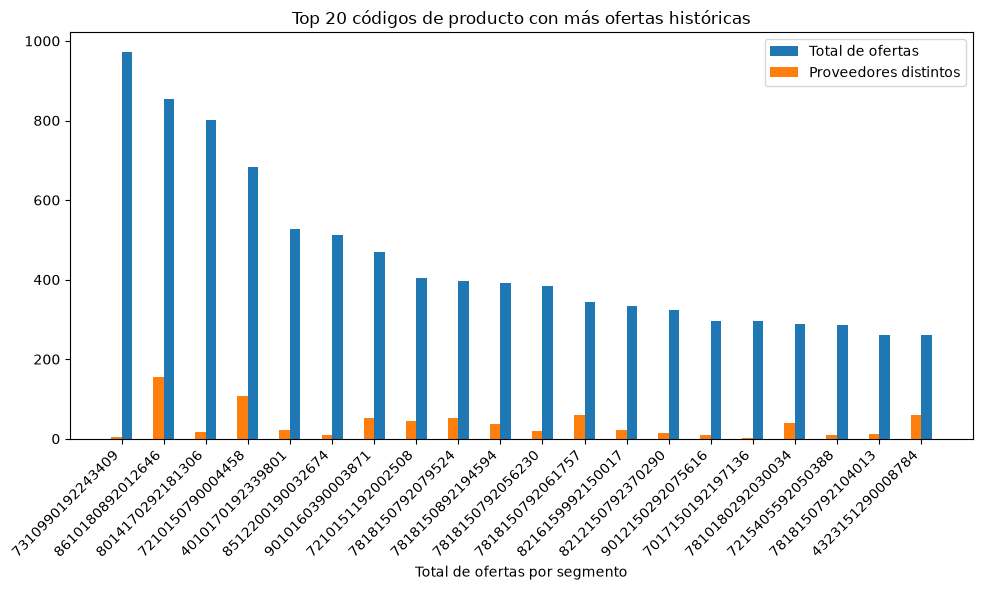

In [44]:
# top productos por total de ofertas
df_productos = con.execute("""
    SELECT
        o.cod_producto,
        p.descripcion_producto,
        p.segmento,
        p.nombre_segmento,
        COUNT(*) AS total_ofertas,
        COUNT(DISTINCT o.nro_sicop || '-' || o.nro_linea) AS lineas_distintas,
        COUNT(DISTINCT o.cedula_proveedor) AS proveedores_distintos
    FROM final.fact_lineas_ofertas o
    LEFT JOIN final.dim_productos p ON p.cod_producto = TRY_CAST(o.cod_producto AS BIGINT)
    GROUP BY o.cod_producto, p.descripcion_producto, p.segmento, p.nombre_segmento
    ORDER BY total_ofertas DESC
""").df()

top20 = df_productos.head(20).copy()
top20["etiqueta"] = top20["descripcion_producto"].fillna(top20["cod_producto"]).str.slice(0, 40)

x = np.arange(len(top20["segmento"]))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(x + width/2, top20["total_ofertas"], width, label="Total de ofertas")
ax.bar(x - width/2, top20["proveedores_distintos"], width, label="Proveedores distintos")

ax.set_xlabel("Total de ofertas por segmento")
ax.set_title("Top 20 códigos de producto con más ofertas históricas")

ax.set_xticks(x)
ax.set_xticklabels(top20["cod_producto"], rotation=45, ha="right")


ax.legend()

plt.tight_layout()
plt.show()


Total de segmentos con ofertas distintos: 57


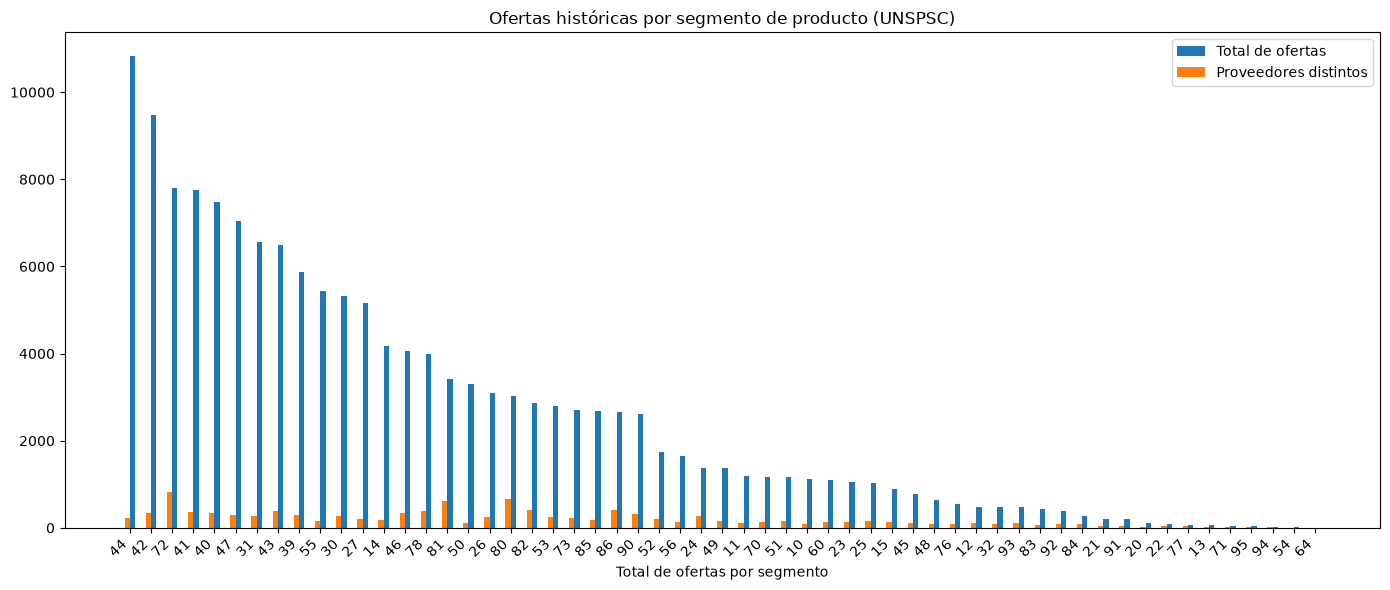

In [56]:
# top segmentos por total de ofertas
df_segmentos = con.execute("""
    SELECT
        p.segmento,
        p.nombre_segmento,
        COUNT(*) AS total_ofertas,
        COUNT(DISTINCT o.nro_sicop || '-' || o.nro_linea) AS lineas_distintas,
        COUNT(DISTINCT o.cedula_proveedor) AS proveedores_distintos
    FROM final.fact_lineas_ofertas o
    LEFT JOIN final.dim_productos p ON p.cod_producto = TRY_CAST(o.cod_producto AS BIGINT)
    GROUP BY p.segmento, p.nombre_segmento
    ORDER BY total_ofertas DESC
""").df()

print(f"Total de segmentos con ofertas distintos: {len(df_segmentos)}")

x = np.arange(len(df_segmentos["segmento"]))
width = 0.25

fig, ax = plt.subplots(figsize=(14, 6))

ax.bar(x + width/2, df_segmentos["total_ofertas"], width, label="Total de ofertas")
ax.bar(x - width/2, df_segmentos["proveedores_distintos"], width, label="Proveedores distintos")

ax.set_xlabel("Total de ofertas por segmento")
ax.set_title("Ofertas históricas por segmento de producto (UNSPSC)")

ax.set_xticks(x)
ax.set_xticklabels(df_segmentos["segmento"], rotation=45, ha="right")

ax.legend()

plt.tight_layout()
plt.show()



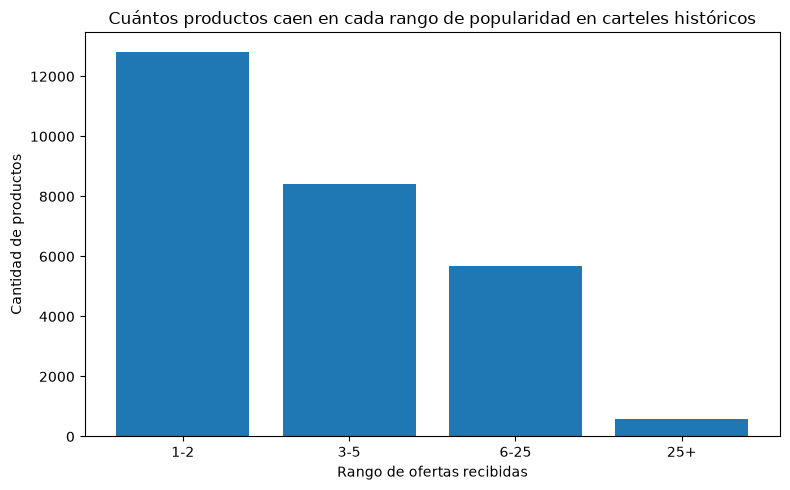

In [48]:
df_buckets = con.execute("""
    WITH ofertas_por_producto AS (
        SELECT cod_producto, COUNT(*) AS total_ofertas
        FROM final.fact_lineas_ofertas
        GROUP BY cod_producto
    )
    SELECT
        CASE
            WHEN total_ofertas BETWEEN 1 AND 2   THEN '1-2'
            WHEN total_ofertas BETWEEN 3 AND 5   THEN '3-5'
            WHEN total_ofertas BETWEEN 6 AND 25  THEN '6-25'
            ELSE '25+'
        END AS rango_ofertas,
        COUNT(*) AS cantidad_productos
    FROM ofertas_por_producto
    GROUP BY 1
""").df()

orden = ["1-2", "3-5", "6-25", "25+"]
df_buckets["rango_ofertas"] = pd.Categorical(df_buckets["rango_ofertas"], categories=orden, ordered=True)
df_buckets = df_buckets.sort_values("rango_ofertas")

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(df_buckets["rango_ofertas"].astype(str), df_buckets["cantidad_productos"])
ax.set_xlabel("Rango de ofertas recibidas")
ax.set_ylabel("Cantidad de productos")
ax.set_title("Cuántos productos caen en cada rango de popularidad en carteles históricos")
plt.tight_layout()
plt.show()

In [49]:
con.sql("""
    SELECT *
    FROM final.dim_proveedores
    LIMIT 5
""").df()

,cedula_proveedor,nombre_proveedor,tipo_proveedor,tamano_proveedor,zona_geo_prov,fecha_registro,porcentaje_exito,productos_distintos_ofertados
0,108190851,ANA MARCELA SOLANO SOLERA,Nacional Físico,Pequeña,"Guadalupe, Goicoechea, San José",2025-02-20,1.000000,1
1,3101773954,VIAJES TRISTAN SOCIEDAD ANONIMA,Nacional Jurídico,Grande,"Catedral, San José, San José",2025-09-08,0.391304,6
2,3101090610,E S CONSULTORIA Y CONSTRUCCION SOCIEDAD ANONIMA,Nacional Jurídico,Pequeña,"Alajuela, Alajuela, Alajuela",2010-05-11,0.093023,24
3,3102032966,TITAN REPRESENTACIONES Y SUMINISTROS LIMITADA,Nacional Jurídico,Mediana,"Guadalupe, Goicoechea, San José",2010-05-20,1.000000,1
4,3101303276,TODO EN FRENOS Y CLUTCH DOS MIL UNO SOCIEDAD A...,Nacional Jurídico,Grande,"Purral, Goicoechea, San José",2012-02-29,0.333333,9


In [50]:
# Cantidad de proveedores por tamaño
con.execute("""
    SELECT
        tamano_proveedor,
        COUNT(*) AS cantidad_proveedores
    FROM final.dim_proveedores
    GROUP BY tamano_proveedor
    ORDER BY cantidad_proveedores DESC
""").df()

,tamano_proveedor,cantidad_proveedores
0,Pequeña,19925
1,Microemprendedor,19790
2,Grande,10578
3,Mediana,7173
4,No clasificado,1007


---
Ahora, exploremos los datos presentes en **fact lineas carteles**.

In [51]:
# Cantidad de carteles por tipo de procedimiento
con.execute("""
    SELECT
        tipo_procedimiento,
        COUNT(*) AS cantidad_lineas_carteles
    FROM final.fact_lineas_carteles
    GROUP BY tipo_procedimiento
    ORDER BY cantidad_lineas_carteles DESC
""").df()

,tipo_procedimiento,cantidad_lineas_carteles
0,LICITACIÓN REDUCIDA,194278
1,LICITACIÓN MENOR,55895
2,LICITACIÓN MAYOR,47490
3,PROCEDIMIENTOS ESPECIALES,31366
4,PROCEDIMIENTO POR EXCEPCIÓN,27794
5,REMATE,1165
6,SUBASTA INVERSA ELECTRÓNICA,296
7,LICITACIÓN PÚBLICA NACIONAL,1


In [52]:
#3. ¿Qué porcentaje de líneas de cartel no tiene NINGUNA oferta?
con.sql("""
SELECT
    COUNT(*) AS total_lineas_cartel,
    COUNT(*) FILTER (WHERE o.n IS NULL) AS sin_ofertas,
    ROUND(100.0 * COUNT(*) FILTER (WHERE o.n IS NULL) / COUNT(*), 1) AS pct_sin_ofertas
FROM final.fact_lineas_carteles c
LEFT JOIN (
    SELECT nro_sicop, nro_linea, COUNT(*) AS n
    FROM final.fact_lineas_ofertas
    GROUP BY nro_sicop, nro_linea
) o ON o.nro_sicop = c.nro_sicop AND o.nro_linea = c.numero_linea;
""").df()

,total_lineas_cartel,sin_ofertas,pct_sin_ofertas
0,358285,310812,86.7


In [53]:
#4. En promedio, ¿cuántas líneas cubre una sola oferta?
con.sql("""
SELECT 
    MAX(lineas_por_oferta) AS maximo,
    MIN(lineas_por_oferta) AS minimo,
    AVG(lineas_por_oferta) AS promedio,
    COUNT(*) AS total_ofertas
FROM (SELECT nro_oferta, COUNT(*) AS lineas_por_oferta
      FROM final.fact_lineas_ofertas GROUP BY nro_oferta)
""").df()

,maximo,minimo,promedio,total_ofertas
0,99,1,1.788616,82007


---
Estadísticas sobre precios en **ofertas**.

In [54]:
con.sql("""
    SELECT *
    FROM final.fact_lineas_ofertas
    LIMIT 5
""").df()

,nro_sicop,nro_oferta,nro_linea,cedula_proveedor,fecha_oferta,tipo_oferta,cod_producto,cantidad_ofertada,tipo_moneda,tipo_cambio_crc,precio_unitario_ofertado,monto_linea_oferta,radio_competitividad,intensidad_competencia,precio_relativo_competidores
0,20250303068,D20250406195520182117439909203440,16,3102688275,2025-04-06,Individual,4010170192328991,2.0,CRC,511.19,2.140000e+06,4280000.00,1.067664,7,0.915282
1,20250301288,D20250411145120158417444046800800,12,3101273008,2025-04-11,Individual,4213220392320514,15000.0,USD,510.17,3.137545e+02,4706318.25,0.506766,7,2.895583
2,20250401133,D20250422084303412517453329837560,46,3101105612,2025-04-22,Individual,4412161892125911,133.0,CRC,505.22,4.880000e+02,64904.00,1.996189,8,0.874552
3,20250400419,D20250410075321370517442932014560,36,3101661822,2025-04-10,Individual,4412170892129094,12.0,CRC,512.07,1.080000e+02,1296.00,8.211759,7,0.629041
4,20250400533,D20250414152206125417446657267510,3,3101735870,2025-04-14,Individual,3210160192179348,30.0,CRC,508.21,7.000000e+03,210000.00,1.252314,7,0.774869


In [55]:
con.sql("""
    SELECT
        MIN(monto_linea_oferta) AS minimo,
        MAX(monto_linea_oferta) AS maximo,
        AVG(monto_linea_oferta) AS promedio,
        MEDIAN(monto_linea_oferta) AS mediana
    FROM final.fact_lineas_ofertas
""").df()

,minimo,maximo,promedio,mediana
0,0.0,1.687973e+11,1.316869e+07,119600.0


---

## 2. Evaluación del clasificador de adjudicación: Random Forest vs. HistGradientBoosting

En esta sección se experimenta **en local** con los modelos.
Reutiliza las mismas variables, la misma consulta de entrenamiento 
y el mismo pipeline de preprocesamiento que `modelo/entrena_y_predice.py`, 
para que lo que midamos aquí sea comparable con lo que corre en el workflow diario.

Compara dos algoritmos sobre **exactamente el mismo conjunto de
entrenamiento y prueba**: Random Forest y `HistGradientBoostingClassifier`.

**Supuesto de ubicación:** este notebook asume que vive en la raíz del
repositorio (junto a `etl/`, `modelo/`, `requirements.txt`) y que Jupyter se
lanzó desde ahí, para poder hacer `from modelo.entrena_y_predice import ...`
directamente. Si se ubica en otra carpeta, será necesario modificar la `RAIZ_PROYECTO` en la
siguiente celda.

In [1]:
import sys
from pathlib import Path

# Asume que este notebook se ejecuta desde la raíz del proyecto, y agrega la raíz del proyecto al path de Python para poder importar los módulos del proyecto.
RAIZ_PROYECTO = Path.cwd() 
if str(RAIZ_PROYECTO) not in sys.path:
    sys.path.insert(0, str(RAIZ_PROYECTO))

#si deseas correr este notebook desde Google Colab, descomenta la siguiente línea y comenta las anteriores
#!git clone https://github.com/ssolorzanocr/Modelo_predictivo_SICOP.git
#sys.path.append('/content/Modelo_predictivo_SICOP/modelo')
#!ls /content/Modelo_predictivo_SICOP/modelo/

In [7]:
import duckdb
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.model_selection import (TimeSeriesSplit, RandomizedSearchCV)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import (
    RocCurveDisplay,
    PrecisionRecallDisplay,
    ConfusionMatrixDisplay,
    classification_report,
    roc_auc_score,
    accuracy_score,
)

# Reutiliza las variables, la consulta, el pipeline Y el criterio de split
# de producción -- así este notebook no puede quedar desincronizado del
# modelo real sin que se note.
from modelo.entrena_y_predice import (
    BUFFER_DIAS_DECISION,
    COLUMNAS_CATEGORICAS,
    COLUMNAS_NUMERICAS,
    CONSULTA_ENTRENAMIENTO,
    construir_pipeline,
    dividir_train_test_cronologico,
)

print("Categóricas:", COLUMNAS_CATEGORICAS)
print("Numéricas:", COLUMNAS_NUMERICAS)
print(f"Buffer de decisión: {BUFFER_DIAS_DECISION} días")

Categóricas: ['tamano_proveedor', 'tipo_procedimiento']
Numéricas: ['proveedores_adjudicados_distintos', 'porcentaje_exito_historico', 'radio_competitividad', 'productos_distintos_historico', 'cantidad_solicitada', 'cantidad_ofertada', 'intensidad_competencia', 'precio_relativo_competidores']
Buffer de decisión: 90 días


### 2.1. Construcción de los datasets de entrenamiento y prueba

Se corre la misma `CONSULTA_ENTRENAMIENTO` que usa el workflow diario --
que ya excluye las ofertas sin decisión todavía confiable. El split es
cronológico (`dividir_train_test_cronologico`), no aleatorio: lo más
antiguo a entrenamiento, lo más reciente a prueba. **Los dos modelos de
este notebook usan exactamente este mismo `X_train`/`X_test`/`y_train`/
`y_test`** -- se construye una sola vez, en esta sección.

In [3]:
from dotenv import load_dotenv
import os
load_dotenv()
RUTA_BASE_DE_DATOS = os.getenv("RUTA_DATOS")
print(f"Ruta de la base de datos: {RUTA_BASE_DE_DATOS}")

con = duckdb.connect(str(RUTA_BASE_DE_DATOS), read_only=True)

df = con.execute(CONSULTA_ENTRENAMIENTO).df()

df["fue_adjudicado"] = df["fue_adjudicado"].astype(bool)
train_df, test_df = dividir_train_test_cronologico(df)

print(f"Filas totales: {len(df):,}")
print(f"Entrenamiento: {len(train_df):,} filas, "
      f"de {train_df['fecha_oferta'].min()} a {train_df['fecha_oferta'].max()}")
print(f"Prueba: {len(test_df):,} filas, "
      f"de {test_df['fecha_oferta'].min()} a {test_df['fecha_oferta'].max()}")

y_train = train_df.pop("fue_adjudicado")
X_train = train_df[COLUMNAS_CATEGORICAS + COLUMNAS_NUMERICAS]
y_test = test_df.pop("fue_adjudicado")
X_test = test_df[COLUMNAS_CATEGORICAS + COLUMNAS_NUMERICAS]

df.head()

Ruta de la base de datos: localdata\sicop.duckdb
Filas totales: 131,572
Entrenamiento: 105,257 filas, de 2025-01-07 00:00:00 a 2026-03-19 00:00:00
Prueba: 26,315 filas, de 2026-03-19 00:00:00 a 2026-09-10 00:00:00


,tamano_proveedor,tipo_procedimiento,proveedores_adjudicados_distintos,porcentaje_exito_historico,radio_competitividad,productos_distintos_historico,cantidad_solicitada,cantidad_ofertada,intensidad_competencia,precio_relativo_competidores,fecha_oferta,fue_adjudicado
0,Mediana,LICITACIÓN REDUCIDA,64,0.000000,1.304348,1,1.0,1.0,3,1.136152,2026-05-11,True
1,Microemprendedor,LICITACIÓN REDUCIDA,64,0.552632,1.130000,142,1.0,1.0,1,NaN,2026-06-01,True
2,Grande,LICITACIÓN MENOR,22,0.270270,1.169290,56,1.0,1.0,1,NaN,2026-05-19,True
3,Grande,LICITACIÓN REDUCIDA,645,0.809524,1.337182,163,24.0,24.0,1,NaN,2026-05-19,True
4,Pequeña,LICITACIÓN REDUCIDA,645,0.562500,1.223483,39,1.0,1.0,1,NaN,2026-06-17,True


### Balance de clases

Antes de mirar cualquier métrica, vale la pena confirmar qué tan balanceado
está el problema. Si una clase domina mucho, `accuracy` sola puede ser
engañosa -- por eso las secciones de abajo usan `roc_auc` como métrica
principal de ajuste para los dos modelos, no `accuracy`.

fue_adjudicado
False    0.683841
True     0.316159
Name: proportion, dtype: float64


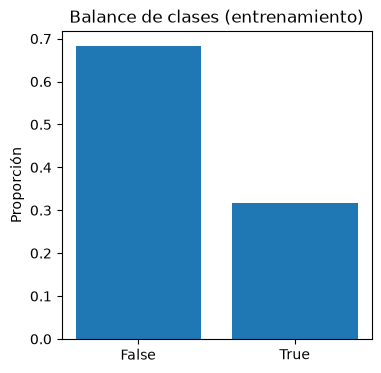

In [4]:
proporcion_clases = y_train.value_counts(normalize=True)
print(proporcion_clases)

fig, ax = plt.subplots(figsize=(4, 4))
ax.bar(proporcion_clases.index.astype(str), proporcion_clases.values)
ax.set_ylabel("Proporción")
ax.set_title("Balance de clases (entrenamiento)")
plt.show()

### 2.2. Ajuste de hiperparámetros -- Random Forest

Se usa `RandomizedSearchCV` en vez de una búsqueda exhaustiva (`GridSearchCV`)
porque el espacio de combinaciones es grande -- prueba una muestra aleatoria
de combinaciones en vez de todas, con validación cruzada de 5 particiones.

La métrica de ajuste es `roc_auc`, no `accuracy` -- dado el desbalance de
clases visto arriba. El prefijo `clasificador__` en cada parámetro viene de
cómo se llama ese paso dentro del `Pipeline` de `construir_pipeline()`.

In [8]:
param_distributions_rf = {
    "clasificador__n_estimators": [50, 100, 150, 200, 300],
    "clasificador__class_weight": [None, "balanced", "balanced_subsample"],
    "clasificador__max_depth": [None, 5, 10, 15, 20, 30],
    "clasificador__min_samples_leaf": [1, 2, 5, 10, 20],
    "clasificador__max_features": ["sqrt", "log2", None],
}

busqueda_rf = RandomizedSearchCV(
    estimator=construir_pipeline(),
    param_distributions=param_distributions_rf,
    n_iter=20,
    scoring="roc_auc",
    cv=TimeSeriesSplit(n_splits=5),
    random_state=42,
    n_jobs=-1,
    verbose=1,
)

busqueda_rf.fit(X_train, y_train)

print("Mejores hiperparámetros (Random Forest):", busqueda_rf.best_params_)
print(f"Mejor AUC promedio (validación cruzada): {busqueda_rf.best_score_:.3f}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Mejores hiperparámetros (Random Forest): {'clasificador__n_estimators': 100, 'clasificador__min_samples_leaf': 20, 'clasificador__max_features': 'sqrt', 'clasificador__max_depth': 20, 'clasificador__class_weight': 'balanced_subsample'}
Mejor AUC promedio (validación cruzada): 0.831


### Resultados de la búsqueda hiperparámetros (Random Forest)

In [10]:
resultados_rf = pd.DataFrame(busqueda_rf.cv_results_)
resultados_rf = resultados_rf.sort_values("mean_test_score", ascending=False)

columnas_interes = [c for c in resultados_rf.columns if c.startswith("param_")] + [
    "mean_test_score", "std_test_score"
]
resultados_rf[columnas_interes].head(5)

,param_clasificador__n_estimators,param_clasificador__min_samples_leaf,param_clasificador__max_features,param_clasificador__max_depth,param_clasificador__class_weight,mean_test_score,std_test_score
14,100,20,sqrt,20,balanced_subsample,0.830891,0.012405
3,100,20,log2,20,NaN,0.830621,0.013018
15,200,10,log2,None,NaN,0.828033,0.013197
4,50,1,log2,10,balanced_subsample,0.827517,0.014315
8,100,5,sqrt,5,balanced,0.827207,0.015106


### 2.3. Ajuste de hiperparámetros -- HistGradientBoostingClassifier

Segundo modelo a comparar: un *gradient boosting* que agrupa valores
numéricos en "bins" en vez de construir árboles sin restricciones -- suele
lograr exactitud similar o mejor que Random Forest con modelos bastante
más livianos (quedó anotado como trabajo futuro en el documento del
modelo).

Usa el **mismo preprocesamiento** que el Random Forest (mismo
`ColumnTransformer`: imputación + One-Hot para categóricas, imputación por
mediana para numéricas), para que la comparación sea justa -- la única
diferencia entre los dos pipelines es el clasificador final.
`HistGradientBoostingClassifier` sí podría recibir las categóricas de forma
nativa (sin One-Hot) y manejar nulos sin imputación previa, pero tomar esa
ruta distinta haría que los dos modelos ya no estén viendo exactamente los
mismos datos de entrada -- se deja como posible mejora futura, no como
parte de esta comparación.

In [11]:
def construir_pipeline_hgb() -> Pipeline:
    """Mismo preprocesamiento que construir_pipeline() (Random Forest, en
    modelo/entrena_y_predice.py) -- se duplica aquí porque esa función tiene
    el clasificador final fijo. Si HistGradientBoostingClassifier termina
    siendo el modelo elegido, vale la pena refactorizar y compartir un solo
    constructor de preprocesador entre ambos pipelines en el archivo de
    producción, en vez de mantener esta copia."""
    transformador_categoricas = Pipeline([
        ("imputar", SimpleImputer(strategy="constant", fill_value="desconocido")),
        ("codificar", OneHotEncoder(handle_unknown="ignore")),
    ])
    transformador_numericas = SimpleImputer(strategy="median")

    preprocesador = ColumnTransformer([
        ("categoricas", transformador_categoricas, COLUMNAS_CATEGORICAS),
        ("numericas", transformador_numericas, COLUMNAS_NUMERICAS),
    ])
    return Pipeline([
        ("preprocesamiento", preprocesador),
        ("clasificador", HistGradientBoostingClassifier(random_state=42)),
    ])

In [12]:
param_distributions_hgb = {
    "clasificador__max_iter": [50, 100, 150, 200, 300],
    "clasificador__learning_rate": [0.01, 0.05, 0.1, 0.2],
    "clasificador__max_depth": [None, 3, 5, 10, 15],
    "clasificador__max_leaf_nodes": [15, 31, 63, 127],
    "clasificador__min_samples_leaf": [10, 20, 50, 100],
    "clasificador__l2_regularization": [0, 0.1, 1.0, 10.0],
}

busqueda_hgb = RandomizedSearchCV(
    estimator=construir_pipeline_hgb(),
    param_distributions=param_distributions_hgb,
    n_iter=20,
    scoring="roc_auc",
    cv=TimeSeriesSplit(n_splits=5),
    random_state=42,
    n_jobs=-1,
    verbose=1,
)

busqueda_hgb.fit(X_train, y_train)

print("Mejores hiperparámetros (HistGradientBoosting):", busqueda_hgb.best_params_)
print(f"Mejor AUC promedio (validación cruzada): {busqueda_hgb.best_score_:.3f}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Mejores hiperparámetros (HistGradientBoosting): {'clasificador__min_samples_leaf': 50, 'clasificador__max_leaf_nodes': 31, 'clasificador__max_iter': 200, 'clasificador__max_depth': 3, 'clasificador__learning_rate': 0.05, 'clasificador__l2_regularization': 10.0}
Mejor AUC promedio (validación cruzada): 0.831


### Resultados de la búsqueda (HistGradientBoostingClassifier)

In [13]:
resultados_hgb = pd.DataFrame(busqueda_hgb.cv_results_).sort_values("mean_test_score", ascending=False)
columnas_interes = [c for c in resultados_hgb.columns if c.startswith("param_")] + [
    "mean_test_score", "std_test_score"
]
top10_hgb = resultados_hgb[columnas_interes].head(10)
top10_hgb

,param_clasificador__min_samples_leaf,param_clasificador__max_leaf_nodes,param_clasificador__max_iter,param_clasificador__max_depth,param_clasificador__learning_rate,param_clasificador__l2_regularization,mean_test_score,std_test_score
9,50,31,200,3,0.05,10.0,0.830739,0.014304
3,100,31,300,15,0.01,10.0,0.827711,0.015104
16,50,15,200,3,0.01,0.0,0.827700,0.012978
1,50,127,100,5,0.05,10.0,0.826778,0.014618
6,50,31,200,3,0.10,10.0,0.826663,0.013715
18,20,15,200,15,0.05,0.0,0.824126,0.015524
4,10,127,50,5,0.05,1.0,0.823992,0.015437
8,50,15,300,None,0.05,0.0,0.820556,0.015828
2,50,63,100,None,0.05,10.0,0.819516,0.017309
15,100,31,150,3,0.20,0.1,0.817584,0.014725


### 2.4. Validación: curva ROC comparada

Los dos modelos ya están reentrenados internamente sobre todo `X_train`
(lo hace `RandomizedSearchCV` al terminar la búsqueda) -- se evalúan ambos
sobre el mismo `X_test`, nunca visto durante el ajuste de ninguno de los
dos.

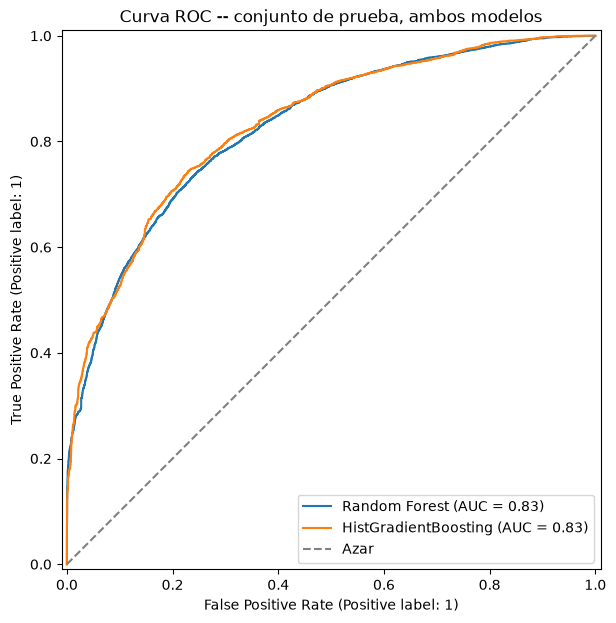

AUC Random Forest:        0.828
AUC HistGradientBoosting: 0.833


In [14]:
mejor_modelo_rf = busqueda_rf.best_estimator_
mejor_modelo_hgb = busqueda_hgb.best_estimator_

probabilidades_test_rf = mejor_modelo_rf.predict_proba(X_test)[:, 1]
probabilidades_test_hgb = mejor_modelo_hgb.predict_proba(X_test)[:, 1]

fig, ax = plt.subplots(figsize=(7, 7))
RocCurveDisplay.from_predictions(y_test, probabilidades_test_rf, ax=ax, name="Random Forest")
RocCurveDisplay.from_predictions(y_test, probabilidades_test_hgb, ax=ax, name="HistGradientBoosting")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Azar")
ax.set_title("Curva ROC -- conjunto de prueba, ambos modelos")
ax.legend()
plt.show()

print(f"AUC Random Forest:        {roc_auc_score(y_test, probabilidades_test_rf):.3f}")
print(f"AUC HistGradientBoosting: {roc_auc_score(y_test, probabilidades_test_hgb):.3f}")

### 2.5 Curva Precision-Recall comparada

Mismo criterio que con la ROC: con clases desbalanceadas, Precision-Recall
suele dar una imagen más honesta que la ROC sola.

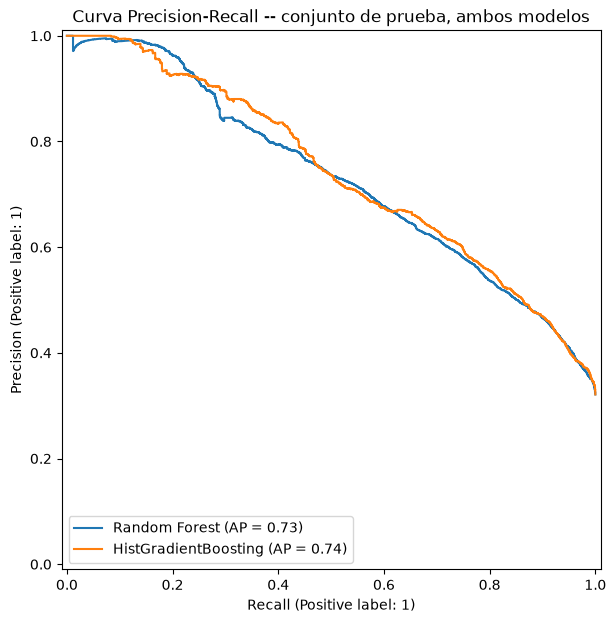

In [15]:
fig, ax = plt.subplots(figsize=(7, 7))
PrecisionRecallDisplay.from_predictions(y_test, probabilidades_test_rf, ax=ax, name="Random Forest")
PrecisionRecallDisplay.from_predictions(y_test, probabilidades_test_hgb, ax=ax, name="HistGradientBoosting")
ax.set_title("Curva Precision-Recall -- conjunto de prueba, ambos modelos")
plt.show()

### 2.6. Evaluación del desempeño con el conjunto de prueba

Métricas "duras" (umbral de decisión 0.5) para los dos modelos, lado a
lado, más la comparación contra el baseline ingenuo.

In [16]:
predicciones_test_rf = mejor_modelo_rf.predict(X_test)
predicciones_test_hgb = mejor_modelo_hgb.predict(X_test)

baseline_ingenuo = y_train.value_counts(normalize=True).max()
print(f"Baseline ingenuo (clase mayoritaria): {baseline_ingenuo:.3f}\n")

print("=== Random Forest ===")
print(f"Exactitud: {accuracy_score(y_test, predicciones_test_rf):.3f}")
print(classification_report(y_test, predicciones_test_rf, target_names=["no_adjudicado", "adjudicado"]))

print("\n=== HistGradientBoosting ===")
print(f"Exactitud: {accuracy_score(y_test, predicciones_test_hgb):.3f}")
print(classification_report(y_test, predicciones_test_hgb, target_names=["no_adjudicado", "adjudicado"]))

Baseline ingenuo (clase mayoritaria): 0.684

=== Random Forest ===
Exactitud: 0.765
               precision    recall  f1-score   support

no_adjudicado       0.85      0.80      0.82     17859
   adjudicado       0.62      0.69      0.65      8456

     accuracy                           0.76     26315
    macro avg       0.73      0.75      0.74     26315
 weighted avg       0.77      0.76      0.77     26315


=== HistGradientBoosting ===
Exactitud: 0.781
               precision    recall  f1-score   support

no_adjudicado       0.80      0.91      0.85     17859
   adjudicado       0.73      0.51      0.60      8456

     accuracy                           0.78     26315
    macro avg       0.76      0.71      0.72     26315
 weighted avg       0.77      0.78      0.77     26315



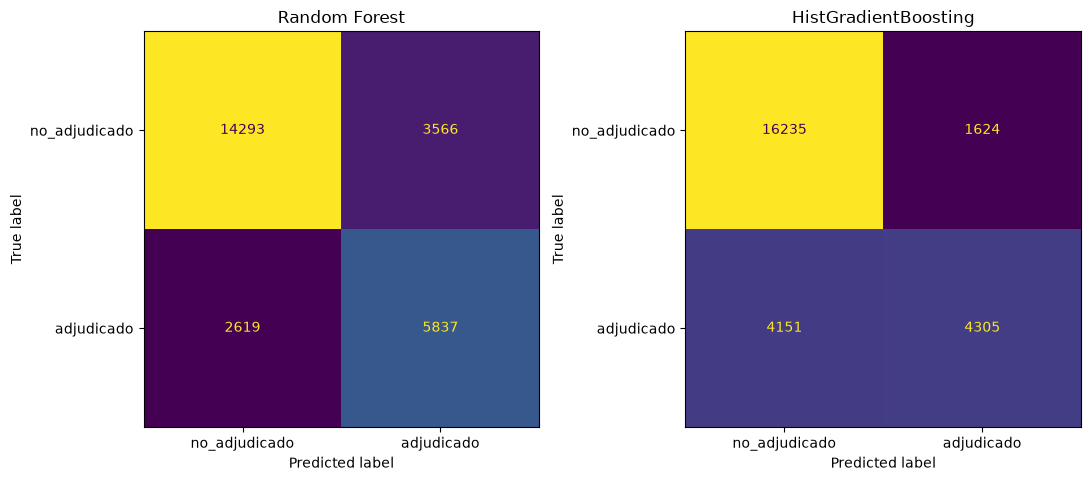

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, predicciones_test_rf, ax=axes[0],
    display_labels=["no_adjudicado", "adjudicado"], colorbar=False,
)
axes[0].set_title("Random Forest")

ConfusionMatrixDisplay.from_predictions(
    y_test, predicciones_test_hgb, ax=axes[1],
    display_labels=["no_adjudicado", "adjudicado"], colorbar=False,
)
axes[1].set_title("HistGradientBoosting")

plt.tight_layout()
plt.show()

### 2.7. Importancia de variables para Random Forest

Solo para Random Forest: `HistGradientBoostingClassifier` no expone
`feature_importances_` como atributo nativo del modelo. La forma
equivalente de medir importancia ahí es *permutation importance*
(`sklearn.inspection.permutation_importance`, aplicable a cualquier
modelo) -- se deja fuera de esta comparación por alcance, pero es el
siguiente paso natural si HistGradientBoosting termina siendo el modelo
elegido.

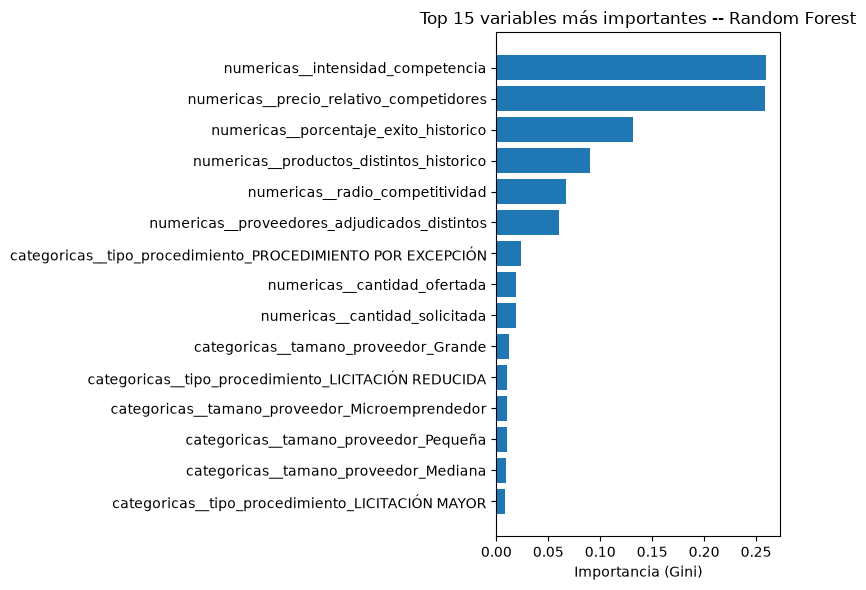

,variable,importancia
16,numericas__intensidad_competencia,0.260022
17,numericas__precio_relativo_competidores,0.258127
11,numericas__porcentaje_exito_historico,0.131029
13,numericas__productos_distintos_historico,0.090032
12,numericas__radio_competitividad,0.067048
10,numericas__proveedores_adjudicados_distintos,0.060687
8,categoricas__tipo_procedimiento_PROCEDIMIENTO ...,0.023987
15,numericas__cantidad_ofertada,0.018813
14,numericas__cantidad_solicitada,0.018484
0,categoricas__tamano_proveedor_Grande,0.011700


In [20]:
nombres_columnas = mejor_modelo_rf.named_steps["preprocesamiento"].get_feature_names_out()
importancias = mejor_modelo_rf.named_steps["clasificador"].feature_importances_

df_importancias = (
    pd.DataFrame({"variable": nombres_columnas, "importancia": importancias})
    .sort_values("importancia", ascending=False)
)

top15 = df_importancias.head(15).iloc[::-1]

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(top15["variable"], top15["importancia"])
ax.set_xlabel("Importancia (Gini)")
ax.set_title("Top 15 variables más importantes -- Random Forest")
plt.tight_layout()
plt.show()

df_importancias

---

## 3. Análisis no supervisado: segmentación de proveedores de SICOP

**Objetivo.** Agrupar a los proveedores que ofertan en SICOP según su *comportamiento*
(volumen, diversificación, éxito, competencia que enfrentan, precio y tamaño de
contrato) para:

1. alimentar el **caso de uso 2 — Caracterización de proveedores** de la herramienta
   (benchmarking: "¿a qué tipo de proveedor me parezco y qué hacen los que ganan?");
2. aportar evidencia a la **hipótesis 3** del primer avance: *existen áreas de
   oportunidad desatendidas*;
3. complementar el modelo supervisado de probabilidad de adjudicación.

**Fuente.** `sicop.duckdb`, publicado por el pipeline automatizado del grupo en el
release `datos_actuales_sicop` del repositorio `Modelo_predictivo_SICOP`
(esquema `final`, datos de enero 2025 a septiembre 2026). Los datos son públicos
(Observatorio de Compra Pública); las cédulas son de personas jurídicas y físicas
registradas como proveedores del Estado. No se publican nombres en las figuras.

In [31]:
# Librerías. duckdb: lectura directa del archivo del pipeline sin servidor.
# scikit-learn: escalado, KMeans, métricas de validación interna y PCA.
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import jinja2
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (adjusted_rand_score, davies_bouldin_score,
                             silhouette_score)
from sklearn.preprocessing import StandardScaler

pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

# Ruta de sicop.duckdb: variable de entorno SICOP_DUCKDB o, si no existe, el clon de
# Modelo_predictivo_SICOP en alguna carpeta superior (estructura de D:\mba).
import os
_candidatas = [p / "Modelo_predictivo_SICOP" / "data" / "sicop.duckdb" for p in Path.cwd().resolve().parents]
#RUTA_DUCKDB = Path(os.environ["SICOP_DUCKDB"]) if os.environ.get("SICOP_DUCKDB") else     next((r for r in _candidatas if r.exists()), _candidatas[1])
RUTA_FIGURAS = Path("../figuras")
RUTA_FIGURAS.mkdir(exist_ok=True)
SEMILLA = 42

# Sistema visual común del grupo (skill dataviz): paleta categórica validada
# para daltonismo, tinta de texto neutra y rejilla discreta.
SERIE = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
TINTA, TINTA_2, TINTA_SUAVE = "#0b0b0b", "#52514e", "#898781"
REJILLA, SUPERFICIE, GRIS_FONDO = "#e1e0d9", "#fcfcfb", "#d6d5cf"
plt.rcParams.update({
    "figure.facecolor": SUPERFICIE, "axes.facecolor": SUPERFICIE,
    "axes.edgecolor": "#c3c2b7", "axes.labelcolor": TINTA_2,
    "axes.titlecolor": TINTA, "axes.titlesize": 12, "axes.titleweight": "bold",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": REJILLA, "grid.linewidth": 0.6,
    "xtick.color": TINTA_SUAVE, "ytick.color": TINTA_SUAVE,
    "font.family": "sans-serif", "font.size": 10, "legend.frameon": False,
})

con = duckdb.connect(str(RUTA_BASE_DE_DATOS), read_only=True)
print(con.execute(
    "SELECT MIN(fecha_publicacion), MAX(fecha_publicacion) FROM final.fact_lineas_carteles"
).fetchone())

(datetime.date(2025, 1, 2), datetime.date(2026, 10, 1))


### 3.1. Construcción del conjunto de datos (unidad de análisis: proveedor)

La consulta `features.sql` agrega las ofertas línea a línea en **una fila por
proveedor**. Decisiones de diseño:

* **Moneda.** Los precios y montos vienen en la moneda original. Se convierten a
  colones con `tipo_cambio_crc` **solo para USD**: se verificó que esa columna
  contiene el tipo de cambio del dólar (~500) incluso en líneas en CRC o EUR, por lo
  que aplicarlo a euros sería incorrecto. Las líneas en otras monedas (≈0,7 % de las
  ofertas) quedan sin precio.
* **Censura de la variable de éxito.** Una oferta en una línea que todavía está en
  evaluación no es una oferta *perdida*. Por eso la tasa de éxito se calcula solo
  sobre **líneas resueltas** (con al menos una adjudicación registrada).
* **Precio relativo.** El precio absoluto no es comparable entre productos; se usa
  la razón entre el precio ofertado y la mediana de las ofertas de la misma línea
  (solo líneas con ≥ 2 ofertas). < 1 = oferta más barata que sus competidores.

In [8]:
# consulta = Path("features.sql").read_text(encoding="utf-8")
# DuckDB ejecuta en paralelo y no garantiza el orden de las filas; KMeans depende
# del orden de los datos. Se ordena por cédula para que el resultado sea reproducible.
base = con.execute("""
    -- Una fila por proveedor que ofertó al menos una vez (ene/2025 - set/2026).
    WITH ofertas AS (
        SELECT o.nro_sicop, o.nro_linea, o.nro_oferta, o.cedula_proveedor, o.cod_producto,
            CASE WHEN o.tipo_moneda = 'CRC' THEN o.precio_unitario_ofertado
                    WHEN o.tipo_moneda = 'USD' AND o.tipo_cambio_crc > 0
                        THEN o.precio_unitario_ofertado * o.tipo_cambio_crc
            END AS precio_crc
        FROM final.fact_lineas_ofertas o
    ),
    -- líneas ya resueltas: alguien fue adjudicado (evita contar como "perdidas"
    -- las ofertas en líneas que siguen en evaluación)
    resueltas AS (
        SELECT DISTINCT nro_sicop, nro_linea FROM final.fact_lineas_adjudicadas
    ),
    ganadas AS (
        SELECT DISTINCT nro_sicop, nro_linea, cedula_proveedor FROM final.fact_lineas_adjudicadas
    ),
    linea_stats AS (
        SELECT nro_sicop, nro_linea,
            COUNT(*)            AS ofertas_en_linea,
            MEDIAN(precio_crc)  AS precio_mediana_linea
        FROM ofertas GROUP BY ALL
    ),
    det AS (
        SELECT o.*, ls.ofertas_en_linea,
            CASE WHEN ls.ofertas_en_linea >= 2 AND ls.precio_mediana_linea > 0
                    THEN o.precio_crc / ls.precio_mediana_linea END AS precio_relativo,
            r.nro_sicop IS NOT NULL AS resuelta,
            g.nro_sicop IS NOT NULL AS ganada,
            p.segmento
        FROM ofertas o
        JOIN linea_stats ls USING (nro_sicop, nro_linea)
        LEFT JOIN resueltas r USING (nro_sicop, nro_linea)
        LEFT JOIN ganadas g ON g.nro_sicop = o.nro_sicop AND g.nro_linea = o.nro_linea
                        AND g.cedula_proveedor = o.cedula_proveedor
        LEFT JOIN final.dim_productos p ON p.cod_producto = TRY_CAST(o.cod_producto AS BIGINT)
    ),
    inst AS (
        SELECT o.cedula_proveedor, COUNT(DISTINCT c.cedula_institucion) AS instituciones
        FROM ofertas o
        JOIN (SELECT DISTINCT nro_sicop, cedula_institucion FROM final.fact_lineas_carteles) c USING (nro_sicop)
        GROUP BY 1
    ),
    adj AS (
        SELECT cedula_proveedor,
            SUM(CASE WHEN tipo_moneda = 'CRC' THEN monto_adjudicado_linea
                        WHEN tipo_moneda = 'USD' AND tipo_cambio_crc > 0
                            THEN monto_adjudicado_linea * tipo_cambio_crc END) AS monto_adjudicado_crc
        FROM final.fact_lineas_adjudicadas GROUP BY 1
    )
    SELECT d.cedula_proveedor,
        pr.tamano_proveedor, pr.tipo_proveedor, pr.zona_geo_prov,
        COUNT(*)                                        AS lineas_ofertadas,
        COUNT(DISTINCT d.nro_sicop)                     AS procedimientos,
        COUNT(DISTINCT d.segmento)                      AS segmentos,
        ANY_VALUE(i.instituciones)                      AS instituciones,
        COUNT(*) FILTER (WHERE d.resuelta)              AS lineas_resueltas,
        COUNT(*) FILTER (WHERE d.resuelta AND d.ganada) AS lineas_ganadas,
        AVG(d.ofertas_en_linea - 1)                     AS competidores_promedio,
        MEDIAN(d.precio_relativo)                       AS precio_relativo_mediana,
        COALESCE(ANY_VALUE(a.monto_adjudicado_crc), 0)  AS monto_adjudicado_crc
    FROM det d
    LEFT JOIN inst i USING (cedula_proveedor)
    LEFT JOIN adj a USING (cedula_proveedor)
    LEFT JOIN final.dim_proveedores pr USING (cedula_proveedor)
    GROUP BY d.cedula_proveedor, pr.tamano_proveedor, pr.tipo_proveedor, pr.zona_geo_prov
    """).df().sort_values("cedula_proveedor").reset_index(drop=True)
print(f"Proveedores con al menos una oferta: {len(base):,}")
base.describe(percentiles=[.5, .9, .99]).T

Proveedores con al menos una oferta: 4,592


,count,mean,std,min,50%,90%,99%,max
lineas_ofertadas,"4,592.000",31.942,167.365,1.000,4.000,60.000,416.270,"7,549.000"
procedimientos,"4,592.000",5.584,16.736,1.000,2.000,12.000,55.090,653.000
segmentos,"4,592.000",2.443,3.174,1.000,1.000,5.000,17.000,43.000
instituciones,"4,398.000",3.507,6.877,1.000,1.000,8.000,30.000,176.000
lineas_resueltas,"4,592.000",28.249,149.433,0.000,4.000,56.000,364.900,"6,882.000"
lineas_ganadas,"4,592.000",10.281,39.036,0.000,1.000,22.000,151.270,"1,031.000"
competidores_promedio,"4,592.000",3.181,3.501,0.000,2.415,6.923,17.000,35.000
precio_relativo_mediana,"3,748.000","15,290.188","907,045.644",0.000,1.000,1.281,422.101,"55,525,000.000"
monto_adjudicado_crc,"4,592.000","41,366,586,396.521","917,027,283,131.403",0.000,"2,236,500.080","4,901,765,071.525","381,344,715,756.043","53,943,884,572,851.562"


### Población del clustering

Con menos de 5 líneas resueltas la tasa de éxito es ruido (0 %, 50 % o 100 % por
azar). Se segmentan los proveedores con **≥ 5 líneas resueltas**; el resto se
describe aparte como *proveedores ocasionales*.

In [9]:
MIN_RESUELTAS = 5
pob = base[base["lineas_resueltas"] >= MIN_RESUELTAS].copy()
ocasionales = base[base["lineas_resueltas"] < MIN_RESUELTAS]
print(f"En el clustering: {len(pob):,}  ·  ocasionales: {len(ocasionales):,}")
print(f"Las líneas ofertadas por la población cubren el "
      f"{pob['lineas_ofertadas'].sum() / base['lineas_ofertadas'].sum():.1%} del total.")

En el clustering: 2,117  ·  ocasionales: 2,475
Las líneas ofertadas por la población cubren el 96.4% del total.


### 3.2. Preprocesamiento

| Variable | Definición | Transformación | Motivo |
|---|---|---|---|
| `log_lineas` | líneas ofertadas | `log1p` | cola larga (máx. > 6.000, mediana 4) |
| `log_segmentos` | segmentos UNSPSC distintos | `log` | asimetría; mide diversificación |
| `log_instituciones` | instituciones distintas | `log` (nulos → 1) | asimetría; 34 sin institución enlazada |
| `tasa_exito` | ganadas / resueltas | ninguna | ya acotada en [0, 1] |
| `log_competidores` | competidores promedio por línea | `log1p` | asimetría |
| `log_precio_rel` | mediana del precio relativo | recorte [0,25; 4] y `log` | valores extremos por errores de unidad; el log hace simétrico "la mitad" y "el doble" |
| `log_ticket` | monto adjudicado / línea ganada (CRC) | `log1p` | montos de 0 a 3·10¹⁰ |

Después, **`StandardScaler`**: KMeans usa distancia euclídea, y sin escalar el monto
(millones) dominaría sobre la tasa (0–1). Se prefirió al `MinMaxScaler` porque este
último es sensible a los extremos que siguen presentes tras el log.
Los proveedores sin precio relativo (sin líneas con competencia) reciben 1
(neutral) — imputación documentada, no se descartan.

In [10]:
pob["instituciones"] = pob["instituciones"].fillna(1)
pob["tasa_exito"] = pob["lineas_ganadas"] / pob["lineas_resueltas"]
pob["precio_rel"] = pob["precio_relativo_mediana"].clip(0.25, 4).fillna(1.0)
pob["ticket"] = np.where(pob["lineas_ganadas"] > 0,
                         pob["monto_adjudicado_crc"] / pob["lineas_ganadas"].clip(lower=1), 0)

X = pd.DataFrame({
    "log_lineas": np.log1p(pob["lineas_ofertadas"]),
    "log_segmentos": np.log(pob["segmentos"]),
    "log_instituciones": np.log(pob["instituciones"]),
    "tasa_exito": pob["tasa_exito"],
    "log_competidores": np.log1p(pob["competidores_promedio"]),
    "log_precio_rel": np.log(pob["precio_rel"]),
    "log_ticket": np.log1p(pob["ticket"]),
}, index=pob.index)

crudas = pob[["lineas_ofertadas", "segmentos", "instituciones", "tasa_exito",
              "competidores_promedio", "precio_rel", "ticket"]]
asimetria = pd.DataFrame({"antes": crudas.skew().values, "después": X.skew().values},
                         index=X.columns)
asimetria

,antes,después
log_lineas,18.225,0.934
log_segmentos,3.267,0.509
log_instituciones,7.555,0.486
tasa_exito,0.423,0.423
log_competidores,2.105,-0.329
log_precio_rel,3.931,-0.915
log_ticket,24.133,-0.666


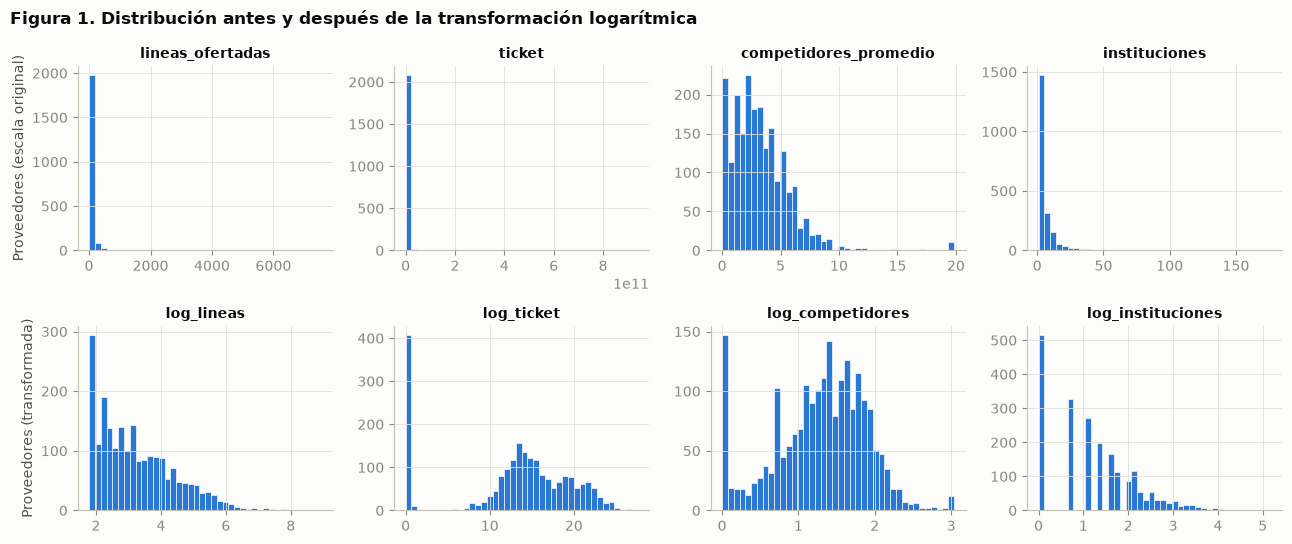

In [12]:
fig, ejes = plt.subplots(2, 4, figsize=(13, 5.5))
pares = [("lineas_ofertadas", "log_lineas"), ("ticket", "log_ticket"),
         ("competidores_promedio", "log_competidores"), ("instituciones", "log_instituciones")]
for col, (cruda, trans) in enumerate(pares):
    ejes[0, col].hist(crudas[cruda], bins=40, color=SERIE[0], edgecolor=SUPERFICIE, linewidth=0.5)
    ejes[0, col].set_title(cruda, fontsize=10)
    ejes[1, col].hist(X[trans], bins=40, color=SERIE[0], edgecolor=SUPERFICIE, linewidth=0.5)
    ejes[1, col].set_title(trans, fontsize=10)
ejes[0, 0].set_ylabel("Proveedores (escala original)")
ejes[1, 0].set_ylabel("Proveedores (transformada)")
fig.suptitle("Figura 1. Distribución antes y después de la transformación logarítmica",
             x=0.01, ha="left", fontweight="bold", color=TINTA)
fig.tight_layout()
#fig.savefig(RUTA_FIGURAS / "fig1_transformaciones.png", dpi=160)
plt.show()

In [13]:
escalador = StandardScaler()
Z = escalador.fit_transform(X)
X.corr().round(2)

,log_lineas,log_segmentos,log_instituciones,tasa_exito,log_competidores,log_precio_rel,log_ticket
log_lineas,1.000,0.640,0.550,-0.070,0.090,0.060,0.200
log_segmentos,0.640,1.000,0.530,-0.120,0.170,0.010,0.190
log_instituciones,0.550,0.530,1.000,-0.070,0.180,0.040,0.330
tasa_exito,-0.070,-0.120,-0.070,1.000,-0.670,-0.020,0.510
log_competidores,0.090,0.170,0.180,-0.670,1.000,0.010,-0.290
log_precio_rel,0.060,0.010,0.040,-0.020,0.010,1.000,0.070
log_ticket,0.200,0.190,0.330,0.510,-0.290,0.070,1.000


Las correlaciones más altas (volumen, segmentos e instituciones, 0,5–0,65) son
esperables: quien oferta más, lo hace en más mercados. No superan 0,7, así que se
mantienen las tres; juntas describen la *amplitud* del proveedor.

### 3.3. Elección del algoritmo y del número de grupos

**KMeans** porque: las variables son continuas y quedan escaladas; el objetivo es un
número pequeño de perfiles interpretables (centroides = "proveedor típico" de cada
grupo) que se puedan mostrar en la aplicación; y asigna cualquier proveedor nuevo al
centroide más cercano, lo que permite usarlo en producción. Alternativas
consideradas: DBSCAN (no produce perfiles comparables y marca como ruido a los
proveedores atípicos, que son justamente los grandes) y clustering jerárquico
(O(n²) en memoria, sin ventaja interpretativa aquí).

Se evalúa k = 2…8 con cuatro criterios: inercia (codo), coeficiente de silueta
(↑), índice de Davies-Bouldin (↓) y **estabilidad** (ARI medio entre la solución
con semilla 42 y tres semillas distintas; 1 = misma partición).

In [14]:
filas = []
modelos = {}
for k in range(2, 9):
    km = KMeans(n_clusters=k, n_init=20, random_state=SEMILLA).fit(Z)
    modelos[k] = km
    ari = np.mean([adjusted_rand_score(km.labels_,
                   KMeans(n_clusters=k, n_init=20, random_state=s).fit(Z).labels_)
                   for s in (1, 2, 3)])
    filas.append({"k": k, "inercia": km.inertia_,
                  "silueta": silhouette_score(Z, km.labels_),
                  "davies_bouldin": davies_bouldin_score(Z, km.labels_),
                  "estabilidad_ARI": ari,
                  "tamaño_min": np.bincount(km.labels_).min()})
evaluacion = pd.DataFrame(filas).set_index("k")
evaluacion

,inercia,silueta,davies_bouldin,estabilidad_ARI,tamaño_min
k,,,,,
2,"11,558.133",0.208,1.642,0.997,720
3,"8,820.260",0.255,1.345,0.998,689
4,"7,581.674",0.240,1.461,0.995,420
5,"6,635.162",0.258,1.296,0.998,109
6,"6,161.732",0.243,1.405,0.997,109
7,"5,830.978",0.219,1.489,0.991,108
8,"5,539.355",0.223,1.418,0.841,52


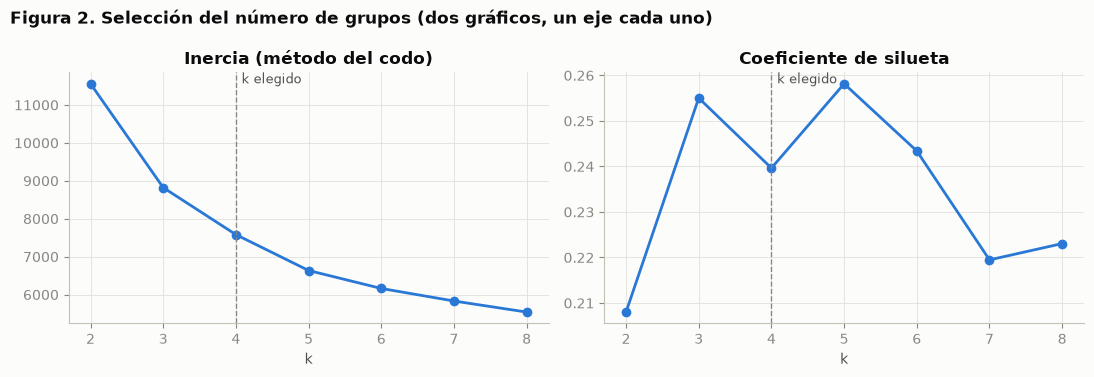

In [17]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3.8))
a1.plot(evaluacion.index, evaluacion["inercia"], color=SERIE[0], lw=2, marker="o", ms=6)
a1.set_title("Inercia (método del codo)")
a1.set_xlabel("k")
a2.plot(evaluacion.index, evaluacion["silueta"], color=SERIE[0], lw=2, marker="o", ms=6)
a2.set_title("Coeficiente de silueta")
a2.set_xlabel("k")
for eje in (a1, a2):
    eje.axvline(4, color=TINTA_SUAVE, lw=1, ls="--")
    eje.annotate("k elegido", (4, eje.get_ylim()[1]), xytext=(4.1, 0), textcoords="offset points",
                 color=TINTA_2, va="top", fontsize=9)
fig.suptitle("Figura 2. Selección del número de grupos (dos gráficos, un eje cada uno)",
             x=0.01, ha="left", fontweight="bold", color=TINTA)
fig.tight_layout()
#fig.savefig(RUTA_FIGURAS / "fig2_seleccion_k.png", dpi=160)
plt.show()

**Decisión: k = 4.** k = 3 tiene la silueta máxima (0,27) pero la diferencia con
k = 4 es de apenas 0,01 — ambas son estructuras de fuerza moderada (0,25–0,5), algo
esperable en datos de comportamiento que forman un continuo. k = 4 se elige por
**utilidad para el caso de uso**: separa un grupo de *proveedores de nicho* (ganan
casi todo lo que ofertan, con menos de un competidor por línea) que en k = 3 queda
mezclado con los ganadores de alto volumen. La partición es estable (ARI ≥ 0,98) y
el grupo más pequeño tiene cientos de proveedores. k ≥ 5 genera grupos de < 50
proveedores (atípicos de precio) sin lectura de negocio nueva.

In [18]:
K = 4
km = modelos[K]
pob["cluster_crudo"] = km.labels_

# Nombres de negocio asignados a partir de los centroides (ver tabla siguiente).
# Se asignan por reglas sobre los centroides y no por número de cluster, para que
# el nombre no dependa del orden arbitrario que devuelve KMeans.
centroides = pd.DataFrame(escalador.inverse_transform(km.cluster_centers_), columns=X.columns)
orden = {}
orden[centroides["log_lineas"].idxmax()] = "Generalistas de alto volumen"
restantes = [i for i in centroides.index if i not in orden]
orden[centroides.loc[restantes, "tasa_exito"].idxmin()] = "Sin adjudicaciones"
restantes = [i for i in centroides.index if i not in orden]
orden[centroides.loc[restantes, "log_competidores"].idxmin()] = "Nicho con poca competencia"
restantes = [i for i in centroides.index if i not in orden]
orden[restantes[0]] = "Competidores focalizados"
NOMBRES = ["Generalistas de alto volumen", "Competidores focalizados",
           "Nicho con poca competencia", "Sin adjudicaciones"]
pob["segmento_proveedor"] = pd.Categorical(pob["cluster_crudo"].map(orden), NOMBRES, ordered=True)

perfil = pob.groupby("segmento_proveedor", observed=True).agg(
    proveedores=("cedula_proveedor", "size"),
    lineas_ofertadas_mediana=("lineas_ofertadas", "median"),
    segmentos_mediana=("segmentos", "median"),
    instituciones_mediana=("instituciones", "median"),
    tasa_exito_mediana=("tasa_exito", "median"),
    competidores_mediana=("competidores_promedio", "median"),
    precio_relativo_mediana=("precio_rel", "median"),
    ticket_mediana_crc=("ticket", "median"),
    monto_total_crc=("monto_adjudicado_crc", "sum"),
)
perfil["%_monto_adjudicado"] = perfil["monto_total_crc"] / perfil["monto_total_crc"].sum()
perfil

,proveedores,lineas_ofertadas_mediana,segmentos_mediana,instituciones_mediana,tasa_exito_mediana,competidores_mediana,precio_relativo_mediana,ticket_mediana_crc,monto_total_crc,%_monto_adjudicado
segmento_proveedor,,,,,,,,,,
Generalistas de alto volumen,452,114.000,8.000,11.000,0.326,3.217,1.000,"3,671,072.499","35,334,988,391,596.438",0.547
Competidores focalizados,695,17.000,2.000,4.000,0.267,3.622,1.000,"4,925,000.000","9,178,212,677,770.184",0.142
Nicho con poca competencia,550,11.000,2.000,2.000,1.000,0.802,1.000,"3,639,530.045","20,012,678,257,857.855",0.310
Sin adjudicaciones,420,11.000,2.000,1.000,0.000,4.000,1.000,0.000,"32,986,843,110.003",0.001


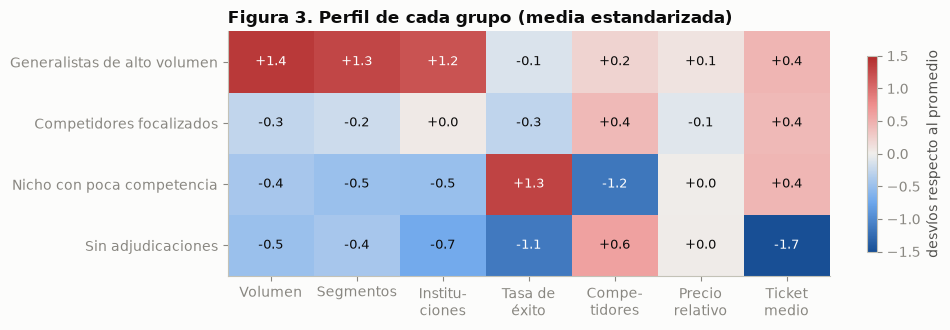

In [19]:
# Perfil estandarizado de cada grupo: media de cada variable escalada (z).
# Divergente azul-rojo con punto medio gris: 0 = promedio de la población.
from matplotlib.colors import LinearSegmentedColormap
divergente = LinearSegmentedColormap.from_list(
    "azul_rojo", ["#184f95", "#6da7ec", "#f0efec", "#ef8f8e", "#b02a2a"])
z_medias = pd.DataFrame(Z, columns=X.columns, index=pob.index) \
    .groupby(pob["segmento_proveedor"], observed=True).mean()
etiquetas = {"log_lineas": "Volumen", "log_segmentos": "Segmentos", "log_instituciones": "Institu-\nciones",
             "tasa_exito": "Tasa de\néxito", "log_competidores": "Compe-\ntidores",
             "log_precio_rel": "Precio\nrelativo", "log_ticket": "Ticket\nmedio"}
fig, eje = plt.subplots(figsize=(10, 3.4))
im = eje.imshow(z_medias.values, cmap=divergente, vmin=-1.5, vmax=1.5, aspect="auto")
eje.set_xticks(range(len(z_medias.columns)), [etiquetas[c] for c in z_medias.columns])
eje.set_yticks(range(len(z_medias.index)), z_medias.index)
eje.grid(False)
for i in range(z_medias.shape[0]):
    for j in range(z_medias.shape[1]):
        v = z_medias.iat[i, j]
        eje.text(j, i, f"{v:+.1f}", ha="center", va="center", fontsize=9,
                 color="#ffffff" if abs(v) > 0.9 else TINTA)
fig.colorbar(im, ax=eje, shrink=0.8, label="desvíos respecto al promedio")
eje.set_title("Figura 3. Perfil de cada grupo (media estandarizada)", loc="left")
fig.tight_layout()
fig.savefig(RUTA_FIGURAS / "fig3_perfil_grupos.png", dpi=160)
plt.show()

### 3.4. Visualización con PCA

Reducción de dimensionalidad solo para **visualizar** (el clustering se hizo en las
7 dimensiones). Con 4 grupos, un único gráfico de dispersión a color no garantiza
distinguibilidad para personas con daltonismo (la paleta valida hasta 3 colores
en dispersión), así que se usan **pequeños múltiplos**: cada panel resalta un
grupo sobre el resto en gris.

Varianza explicada: [0.33  0.285] · total 0.615
                     CP1    CP2
log_lineas         0.550  0.060
log_segmentos      0.550  0.010
log_instituciones  0.540  0.070
tasa_exito        -0.130  0.630
log_competidores   0.200 -0.560
log_precio_rel     0.060  0.030
log_ticket         0.210  0.530


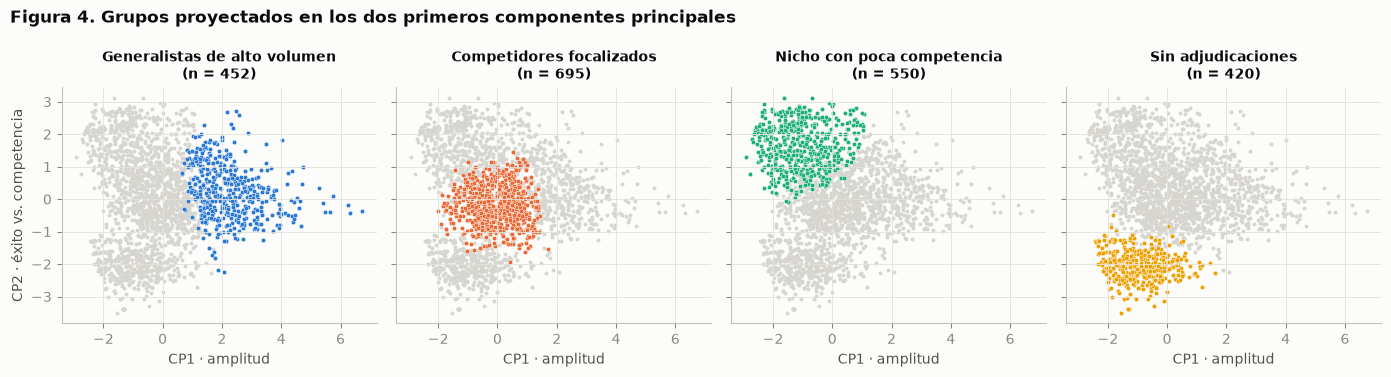

In [20]:
pca = PCA(n_components=2, random_state=SEMILLA)
P = pca.fit_transform(Z)
print("Varianza explicada:", pca.explained_variance_ratio_.round(3),
      "· total", pca.explained_variance_ratio_.sum().round(3))
cargas = pd.DataFrame(pca.components_.T, index=X.columns, columns=["CP1", "CP2"])
print(cargas.round(2))

fig, ejes = plt.subplots(1, 4, figsize=(14, 3.8), sharex=True, sharey=True)
for eje, nombre, color in zip(ejes, NOMBRES, SERIE):
    m = (pob["segmento_proveedor"] == nombre).values
    eje.scatter(P[~m, 0], P[~m, 1], s=8, color=GRIS_FONDO, lw=0)
    eje.scatter(P[m, 0], P[m, 1], s=10, color=color, lw=0.3, edgecolor=SUPERFICIE)
    eje.set_title(f"{nombre}\n(n = {m.sum():,})", fontsize=10)
    eje.set_xlabel("CP1 · amplitud")
ejes[0].set_ylabel("CP2 · éxito vs. competencia")
fig.suptitle("Figura 4. Grupos proyectados en los dos primeros componentes principales",
             x=0.01, ha="left", fontweight="bold", color=TINTA)
fig.tight_layout()
fig.savefig(RUTA_FIGURAS / "fig4_pca_grupos.png", dpi=160)
plt.show()

### 3.5. ¿El tamaño de empresa explica los grupos?

El tamaño (`tamano_proveedor`) **no** se usó para formar los grupos: se reserva
para validar externamente la segmentación y responder una pregunta del TFM: ¿las
MIPYMES se comportan distinto de las grandes?

tamano_proveedor,Microemprendedor,Pequeña,Mediana,Grande
segmento_proveedor,,,,
Generalistas de alto volumen,13%,38%,26%,23%
Competidores focalizados,16%,43%,24%,18%
Nicho con poca competencia,15%,38%,24%,22%
Sin adjudicaciones,18%,42%,22%,18%


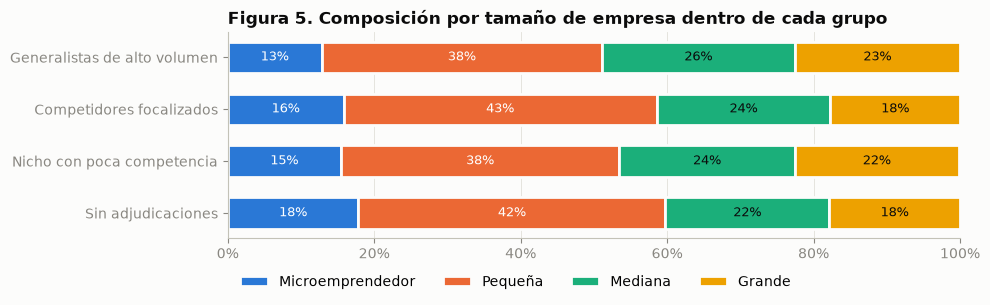

chi² = 13.4, gl = 9, p = 0.145, V de Cramér = 0.046


In [23]:
ORDEN_TAMANO = ["Microemprendedor", "Pequeña", "Mediana", "Grande"]
comp = pd.crosstab(pob["segmento_proveedor"], pob["tamano_proveedor"], normalize="index")
comp = comp.reindex(columns=ORDEN_TAMANO).fillna(0)
display(comp.style.format("{:.0%}"))

fig, eje = plt.subplots(figsize=(10, 3.2))
izquierda = np.zeros(len(comp))
for j, tam in enumerate(ORDEN_TAMANO):
    eje.barh(comp.index.astype(str), comp[tam], left=izquierda, color=SERIE[j],
             edgecolor=SUPERFICIE, linewidth=2, label=tam, height=0.6)
    for i, v in enumerate(comp[tam]):
        if v >= 0.08:
            eje.text(izquierda[i] + v / 2, i, f"{v:.0%}", ha="center", va="center",
                     fontsize=9, color="#ffffff" if j in (0, 1) else TINTA)
    izquierda += comp[tam].values
eje.invert_yaxis()
eje.set_axisbelow(True)
eje.set_xlim(0, 1)
eje.xaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
eje.grid(axis="y", visible=False)
eje.legend(ncols=4, loc="upper left", bbox_to_anchor=(0, -0.12))
eje.set_title("Figura 5. Composición por tamaño de empresa dentro de cada grupo", loc="left")
fig.tight_layout()
#fig.savefig(RUTA_FIGURAS / "fig5_tamano_por_grupo.png", dpi=160)
plt.show()

# Contraste chi-cuadrado de independencia entre grupo y tamaño.
from scipy.stats import chi2_contingency
tabla = pd.crosstab(pob["segmento_proveedor"], pob["tamano_proveedor"]).reindex(columns=ORDEN_TAMANO).fillna(0)
chi2, p, gl, _ = chi2_contingency(tabla)
v_cramer = np.sqrt(chi2 / (tabla.values.sum() * (min(tabla.shape) - 1)))
print(f"chi² = {chi2:.1f}, gl = {gl}, p = {p:.3g}, V de Cramér = {v_cramer:.3f}")

### 3.6. Hipótesis 3: mapa de oportunidades por segmento de producto

Complemento a nivel de **mercado**: para cada segmento UNSPSC se cruza la demanda
(líneas publicadas) con la competencia (ofertas por línea) y el porcentaje de
líneas publicadas que no recibieron ninguna oferta. Un segmento con mucha demanda y
poca competencia es un candidato a "área desatendida".

**Nota de cobertura (hallazgo de calidad de datos).** En la versión del
`sicop.duckdb` usada (release del 24/09/2026) solo ~12 % de los procedimientos de
`fact_lineas_carteles` tienen alguna oferta en `fact_lineas_ofertas` (la celda
siguiente lo cuantifica por mes). Si se usaran todos los carteles, "sin ofertas"
mediría la falta de datos y no la falta de competencia. Por eso el análisis se
restringe a los procedimientos **con cobertura de ofertas**, y el hallazgo se
reporta al responsable del pipeline.

In [24]:
cobertura = con.execute('''
    SELECT strftime(fecha_publicacion, '%Y-%m') AS mes,
           COUNT(DISTINCT c.nro_sicop) AS procedimientos,
           COUNT(DISTINCT c.nro_sicop) FILTER (WHERE o.nro_sicop IS NOT NULL) AS con_ofertas
    FROM final.fact_lineas_carteles c
    LEFT JOIN (SELECT DISTINCT nro_sicop FROM final.fact_lineas_ofertas) o USING (nro_sicop)
    GROUP BY 1 ORDER BY 1
''').df()
cobertura["cobertura"] = cobertura["con_ofertas"] / cobertura["procedimientos"]
print(f"Cobertura global: {cobertura['con_ofertas'].sum() / cobertura['procedimientos'].sum():.1%}")
cobertura

Cobertura global: 13.3%


,mes,procedimientos,con_ofertas,cobertura
0,2025-01,1000,230,0.230
1,2025-02,2165,675,0.312
2,2025-03,3005,887,0.295
3,2025-04,2528,681,0.269
4,2025-05,3303,527,0.160
5,2025-06,3232,516,0.160
6,2025-07,3016,334,0.111
7,2025-08,3069,362,0.118
8,2025-09,3240,209,0.065
9,2025-10,4371,308,0.070


In [25]:
mercado = con.execute('''
    WITH ofertas_linea AS (
        SELECT nro_sicop, nro_linea, COUNT(*) AS ofertas
        FROM final.fact_lineas_ofertas GROUP BY ALL
    )
    SELECT p.segmento, p.nombre_segmento,
           COUNT(*)                                            AS lineas_publicadas,
           AVG(COALESCE(o.ofertas, 0))                         AS ofertas_por_linea,
           AVG(CASE WHEN o.ofertas IS NULL THEN 1 ELSE 0 END)  AS pct_sin_ofertas
    FROM final.fact_lineas_carteles c
    JOIN final.dim_productos p ON p.cod_producto = TRY_CAST(c.cod_producto AS BIGINT)
    -- solo procedimientos con cobertura en la tabla de ofertas (ver nota de cobertura)
    JOIN (SELECT DISTINCT nro_sicop FROM final.fact_lineas_ofertas) cov USING (nro_sicop)
    LEFT JOIN ofertas_linea o ON o.nro_sicop = c.nro_sicop AND o.nro_linea = c.numero_linea
    GROUP BY ALL
    HAVING COUNT(*) >= 100
    ORDER BY lineas_publicadas DESC
''').df()
med_dem, med_comp = mercado["lineas_publicadas"].median(), mercado["ofertas_por_linea"].median()
mercado["oportunidad"] = (mercado["lineas_publicadas"] >= med_dem) & (mercado["ofertas_por_linea"] <= med_comp)
print(f"Segmentos analizados: {len(mercado)} · mediana de demanda {med_dem:,.0f} líneas · "
      f"mediana de competencia {med_comp:.2f} ofertas/línea")
mercado[mercado["oportunidad"]].sort_values("lineas_publicadas", ascending=False)

Segmentos analizados: 45 · mediana de demanda 793 líneas · mediana de competencia 2.58 ofertas/línea


,segmento,nombre_segmento,lineas_publicadas,ofertas_por_linea,pct_sin_ofertas,oportunidad
0,42,"Equipo médico, accesorios e insumos",4013,1.966,0.067,True
2,41,"Instrumentos de laboratorio, medición y observ...",2702,2.349,0.053,True
3,55,"Publicaciones, grabaciones y medios de informa...",2654,2.001,0.080,True
5,78,"Servicios de transporte, almacenamiento y correo",2521,1.441,0.014,True
8,81,"Servicios de ingeniería, investigación y tecno...",1751,1.586,0.057,True
10,86,Servicios de educación y formación,1557,1.663,0.036,True
14,90,"Servicios de viaje, alimentación y alojamiento",1377,1.833,0.097,True
16,80,Servicios profesionales de gestión y administr...,1253,2.171,0.049,True
19,82,Servicios editoriales y gráficos,1053,2.566,0.070,True
20,73,Servicios de manufactura industrial,1030,2.417,0.142,True


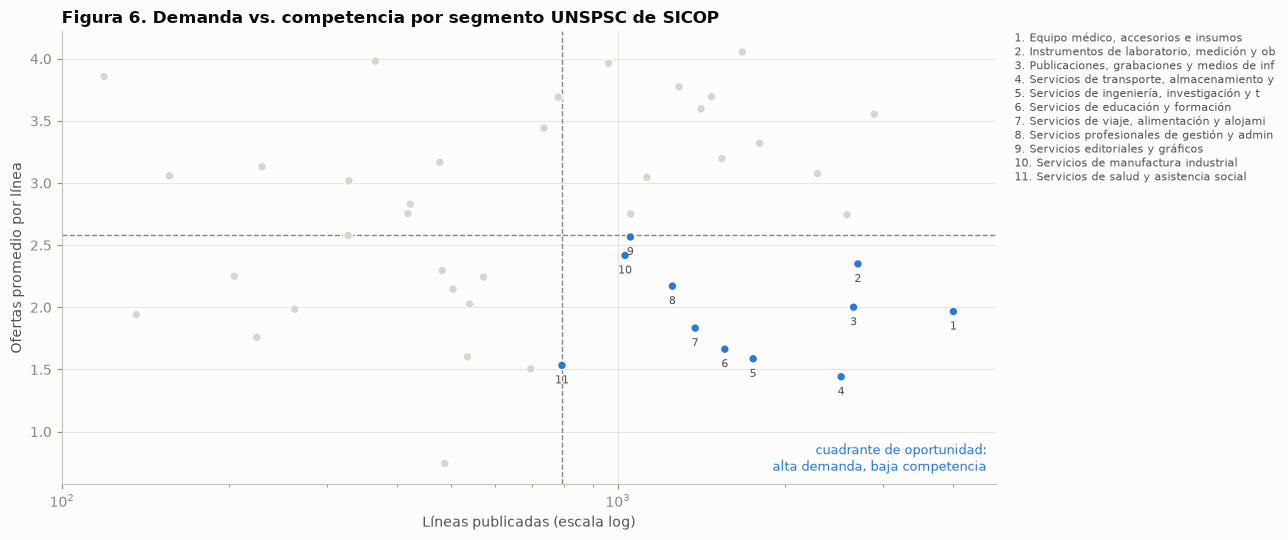

In [26]:
fig, eje = plt.subplots(figsize=(13, 5.5))
eje.scatter(mercado["lineas_publicadas"], mercado["ofertas_por_linea"], s=40,
            color=np.where(mercado["oportunidad"], SERIE[0], GRIS_FONDO),
            edgecolor=SUPERFICIE, lw=1, zorder=3)
eje.set_xscale("log")
eje.axvline(med_dem, color=TINTA_SUAVE, lw=1, ls="--")
eje.axhline(med_comp, color=TINTA_SUAVE, lw=1, ls="--")
# Etiquetas numeradas (el nombre completo va en la tabla de arriba) para evitar
# que los nombres largos de segmento se superpongan.
candidatos = mercado[mercado["oportunidad"]].sort_values("lineas_publicadas", ascending=False)
for n, (_, f) in enumerate(candidatos.iterrows(), start=1):
    eje.annotate(str(n), (f["lineas_publicadas"], f["ofertas_por_linea"]),
                 xytext=(0, -13), textcoords="offset points", ha="center",
                 fontsize=8, color=TINTA_2)
leyenda = "\n".join(f"{n}. {nom[:42]}" for n, nom in enumerate(candidatos["nombre_segmento"], start=1))
eje.text(1.02, 1.0, leyenda, transform=eje.transAxes, va="top", fontsize=8, color=TINTA_2)
eje.text(0.99, 0.02, "cuadrante de oportunidad:\nalta demanda, baja competencia",
         transform=eje.transAxes, ha="right", va="bottom", fontsize=9, color=SERIE[0])
eje.set_xlabel("Líneas publicadas (escala log)")
eje.set_ylabel("Ofertas promedio por línea")
eje.set_title("Figura 6. Demanda vs. competencia por segmento UNSPSC de SICOP", loc="left")
fig.tight_layout()
fig.savefig(RUTA_FIGURAS / "fig6_mapa_oportunidades.png", dpi=160)
plt.show()

### 3.7. Análisis complementarios

#### 3.7.1 Diagrama de silueta (validación de la partición)

La silueta media resume la calidad global; el diagrama muestra **cada proveedor**:
valores negativos indican proveedores que quedarían mejor en otro grupo. Permite ver
si algún grupo es débil o si el problema está repartido.

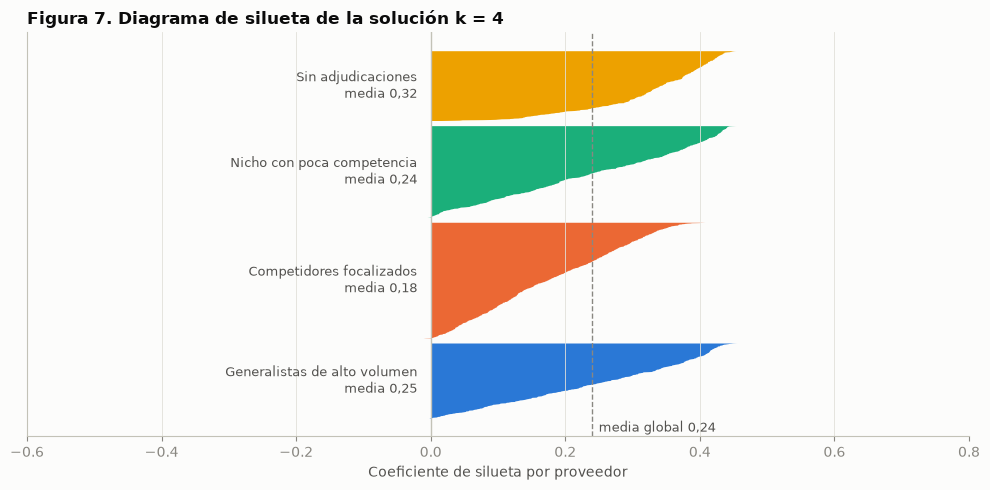

,media,pct_negativos
segmento_proveedor,,
Generalistas de alto volumen,0.250,0.007
Competidores focalizados,0.179,0.003
Nicho con poca competencia,0.244,0.009
Sin adjudicaciones,0.323,0.000


In [27]:
from sklearn.metrics import silhouette_samples
sil = silhouette_samples(Z, km.labels_)
pob["silueta"] = sil
fig, eje = plt.subplots(figsize=(10, 5))
y0 = 0
for nombre, color in zip(NOMBRES, SERIE):
    valores = np.sort(pob.loc[pob["segmento_proveedor"] == nombre, "silueta"].values)
    eje.fill_betweenx(np.arange(y0, y0 + len(valores)), 0, valores, color=color, lw=0)
    eje.text(-0.02, y0 + len(valores) / 2, f"{nombre}\nmedia {valores.mean():.2f}".replace(".", ","),
             ha="right", va="center", fontsize=9, color=TINTA_2)
    y0 += len(valores) + 30
eje.axvline(sil.mean(), color=TINTA_SUAVE, ls="--", lw=1)
eje.text(sil.mean() + 0.01, -15, f"media global {sil.mean():.2f}".replace(".", ","),
         fontsize=9, color=TINTA_2, va="top")
eje.axvline(0, color="#c3c2b7", lw=1)
eje.set_yticks([])
eje.set_xlim(-0.6, 0.8)
eje.set_xlabel("Coeficiente de silueta por proveedor")
eje.set_title("Figura 7. Diagrama de silueta de la solución k = 4", loc="left")
fig.tight_layout()
fig.savefig(RUTA_FIGURAS / "fig7_silueta.png", dpi=160)
plt.show()
resumen_sil = pob.groupby("segmento_proveedor", observed=True)["silueta"].agg(
    media="mean", pct_negativos=lambda s: (s < 0).mean())
resumen_sil

#### 3.7.2 Distribución de las variables clave por grupo

Las medianas de la tabla de perfiles no muestran la dispersión. Los diagramas de
caja permiten ver si los grupos se solapan en cada variable.

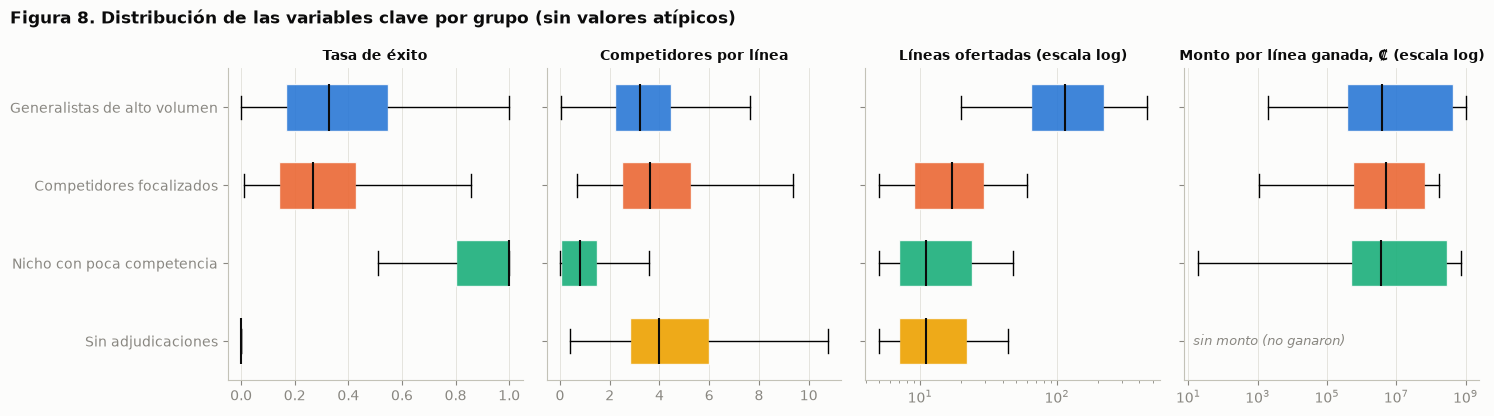

In [28]:
variables_caja = [("tasa_exito", "Tasa de éxito", False),
                  ("competidores_promedio", "Competidores por línea", False),
                  ("lineas_ofertadas", "Líneas ofertadas (escala log)", True),
                  ("ticket", "Monto por línea ganada, ₡ (escala log)", True)]
fig, ejes = plt.subplots(1, 4, figsize=(15, 4.2))
for eje, (col, titulo, logaritmo) in zip(ejes, variables_caja):
    datos_caja = [pob.loc[pob["segmento_proveedor"] == n, col].values for n in NOMBRES]
    if logaritmo:
        # En escala log solo caben valores > 0. Si a un grupo le quedan pocos (p. ej. los
        # «Sin adjudicaciones» no tienen monto), una caja con esos pocos engañaría:
        # se omite y se escribe el motivo.
        positivos = [v[v > 0] for v in datos_caja]
        omitidos = [len(p) < 0.5 * len(v) for p, v in zip(positivos, datos_caja)]
        datos_caja = [p if not o else [] for p, o in zip(positivos, omitidos)]
    else:
        omitidos = [False] * 4
    cajas = eje.boxplot(datos_caja, orientation="horizontal", patch_artist=True, widths=0.6,
                        showfliers=False, medianprops={"color": TINTA, "lw": 1.5})
    for caja, color in zip(cajas["boxes"], SERIE):
        caja.set(facecolor=color, edgecolor=SUPERFICIE, alpha=0.9)
    if logaritmo:
        eje.set_xscale("log")
    for i, o in enumerate(omitidos, start=1):
        if o:
            eje.text(0.03, i, "sin monto (no ganaron)", transform=eje.get_yaxis_transform(),
                     va="center", fontsize=9, color=TINTA_SUAVE, style="italic")
    eje.set_title(titulo, fontsize=10)
    eje.set_yticks(range(1, 5), NOMBRES if eje is ejes[0] else [""] * 4)
    eje.invert_yaxis()
    eje.grid(axis="y", visible=False)
fig.suptitle("Figura 8. Distribución de las variables clave por grupo (sin valores atípicos)",
             x=0.01, ha="left", fontweight="bold", color=TINTA)
fig.tight_layout()
fig.savefig(RUTA_FIGURAS / "fig8_cajas_por_grupo.png", dpi=160)
plt.show()

#### 3.7.3 ¿Gana siempre la oferta más barata?

Nivel **línea**. En las líneas resueltas con al menos dos ofertas con precio, se
ordena el precio de las ofertas (1 = la más barata) y se mira en qué posición estaba
la oferta adjudicada. Si el precio fuera el único criterio, casi todo caería en la
posición 1. La diferencia es el espacio de la **Compra Pública Estratégica** (marco
teórico): criterios técnicos, sociales o el «criterio PYME» pesan en la adjudicación.
Para el proveedor, significa que bajar el precio no basta y que la información sobre
cómo adjudica cada institución tiene valor.

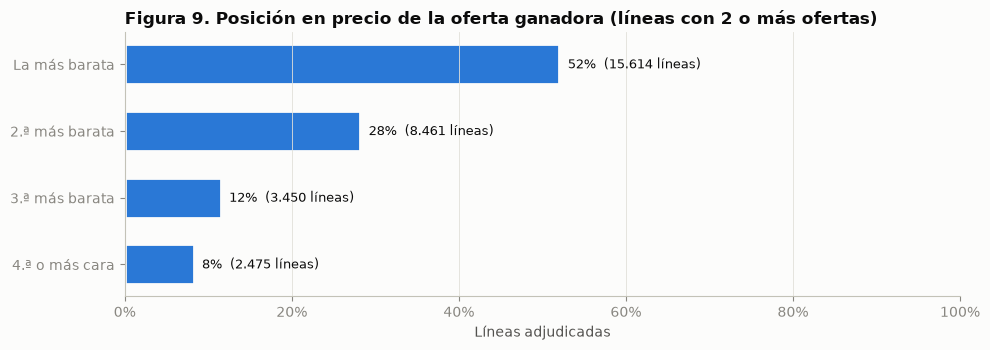

,posicion,lineas,porcentaje
0,1,15614,0.520
1,2,8461,0.282
2,3,3450,0.115
3,4,2475,0.083


In [29]:
posicion_ganador = con.execute(f'''
    WITH ofertas AS (
        SELECT nro_sicop, nro_linea, cedula_proveedor,
               CASE WHEN tipo_moneda = 'CRC' THEN precio_unitario_ofertado
                    WHEN tipo_moneda = 'USD' AND tipo_cambio_crc > 0
                         THEN precio_unitario_ofertado * tipo_cambio_crc END AS precio_crc
        FROM final.fact_lineas_ofertas
        WHERE precio_unitario_ofertado > 0
    ),
    rank_lineas AS (
        SELECT *, RANK() OVER (PARTITION BY nro_sicop, nro_linea ORDER BY precio_crc) AS posicion,
               COUNT(*) OVER (PARTITION BY nro_sicop, nro_linea) AS n_ofertas
        FROM ofertas WHERE precio_crc IS NOT NULL
    ),
    ganadores AS (SELECT DISTINCT nro_sicop, nro_linea, cedula_proveedor FROM final.fact_lineas_adjudicadas)
    SELECT LEAST(r.posicion, 4) AS posicion, COUNT(*) AS lineas
    FROM rank_lineas r
    JOIN ganadores g USING (nro_sicop, nro_linea, cedula_proveedor)
    WHERE r.n_ofertas >= 2
    GROUP BY 1 ORDER BY 1
''').df()
posicion_ganador["porcentaje"] = posicion_ganador["lineas"] / posicion_ganador["lineas"].sum()
etiquetas_pos = {1: "La más barata", 2: "2.ª más barata", 3: "3.ª más barata", 4: "4.ª o más cara"}

fig, eje = plt.subplots(figsize=(10, 3.6))
y = range(len(posicion_ganador))
eje.barh(y, posicion_ganador["porcentaje"], color=SERIE[0], height=0.6, edgecolor=SUPERFICIE, lw=2)
for yi, v, n in zip(y, posicion_ganador["porcentaje"], posicion_ganador["lineas"]):
    eje.text(v + 0.01, yi, f"{v:.0%}  ({n:,} líneas)".replace(",", "."), va="center", fontsize=9, color=TINTA)
eje.set_yticks(list(y), [etiquetas_pos[int(p)] for p in posicion_ganador["posicion"]])
eje.invert_yaxis()
eje.set_xlim(0, 1)
eje.xaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
eje.grid(axis="y", visible=False)
eje.set_xlabel("Líneas adjudicadas")
eje.set_title("Figura 9. Posición en precio de la oferta ganadora (líneas con 2 o más ofertas)", loc="left")
fig.tight_layout()
fig.savefig(RUTA_FIGURAS / "fig9_posicion_precio_ganador.png", dpi=160)
plt.show()
posicion_ganador

### 3.9. Interpretación, relación con el TFM y limitaciones

Ver la sección escrita en la memoria (archivo `Seccion_Asig7_No_Supervisado.docx`),
que se redacta a partir de los resultados impresos arriba. Resumen:

* **Cuatro perfiles de comportamiento** con lectura de negocio directa para el
  benchmarking del UC2.
* **El tamaño de empresa casi no explica el perfil** (ver V de Cramér): el
  comportamiento en el mercado —dónde y contra quién se oferta— distingue más que
  ser MIPYME o grande. Argumento central del TFM: la brecha es de *información*, no
  de tamaño.
* **Hipótesis 3**: el grupo *Nicho con poca competencia* y el cuadrante de
  oportunidad de la Figura 6 son evidencia de espacios con poca competencia.
* **Limitaciones**: la tabla de ofertas cubre solo ~12 % de los procedimientos
  publicados en esta versión de los datos, por lo que los perfiles describen a los
  proveedores *observados*, no a todo el mercado; 20 meses de datos; la tasa de
  éxito depende del enlace oferta↔adjudicación (≈14 mil adjudicaciones sin oferta
  asociada); silueta moderada; las variables describen el pasado, no la capacidad
  de la empresa. Al corregirse la cobertura, basta volver a ejecutar el cuaderno.